# Librerias

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency,shapiro, spearmanr, pearsonr,f_oneway, kruskal,kstest,normaltest,ks_2samp,ttest_ind
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import itertools


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cargado de datos

In [3]:
df=pd.read_csv('base_imputacion_mixta_1000.csv',sep=',',header=0,encoding='utf-8')

In [4]:
df.head()

,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


# Funciones 

In [5]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [6]:
def graficar_numericas(df):
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="gold", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [7]:
def graficar_categoricas(df,categoricas):
    for cat in categoricas:
        print(df[cat].value_counts())
        sns.countplot(data=df, x=cat, order=df[cat].value_counts().index)
        plt.title(f'Distribución de {cat}')
        plt.xticks(rotation=45)
        plt.show()

In [8]:
def analisis_bivariado_todas_numericas(df):
    numericas = df.select_dtypes(include=['int64', 'float64']).columns
    
    for var1, var2 in itertools.combinations(numericas, 2):
        print("="*60)
        print(f"Análisis entre: {var1} y {var2}")
        plt.figure(figsize=(6,4))
        sns.regplot(data=df, x=var1, y=var2, scatter_kws={"alpha":0.5})
        plt.title(f"Relación entre {var1} y {var2}")
        plt.show()
        p1 = shapiro(df[var1].dropna())[1]
        p2 = shapiro(df[var2].dropna())[1]
        
        normal1 = p1 > 0.05
        normal2 = p2 > 0.05
        
        print(f"Shapiro {var1}: p={p1:.4f} -> {'Normal' if normal1 else 'No normal'}")
        print(f"Shapiro {var2}: p={p2:.4f} -> {'Normal' if normal2 else 'No normal'}")
        df_temp = df[[var1, var2]].dropna()
        if normal1 and normal2:
            corr, p = pearsonr(df_temp[var1], df_temp[var2])
            metodo = "Pearson"
        else:
            corr, p = spearmanr(df_temp[var1], df_temp[var2])
            metodo = "Spearman"
        
        print(f"Correlación ({metodo}): {corr:.4f} (p-value={p:.4f})\n")

In [9]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

In [10]:
def cramers_v_imp(ct):
    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    n = ct.to_numpy().sum()
    k = min(ct.shape)-1
    return np.sqrt(chi2 / (n * k)) if n > 0 and k > 0 else np.nan

In [11]:
def analisis_bivariado_categoricas(df):
    categoricas = df.select_dtypes(include=['object', 'category']).columns
    
    for var1, var2 in itertools.combinations(categoricas, 2):
        print("="*70)
        print(f"Análisis entre: {var1} y {var2}")
        tabla = pd.crosstab(df[var1], df[var2])
        print("\nTabla de contingencia:")
        print(tabla)
        plt.figure(figsize=(6,4))
        sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Heatmap: {var1} vs {var2}")
        plt.show()
        chi2, p, dof, expected = chi2_contingency(tabla)
        print(f"\nChi-cuadrado: {chi2:.4f}, p-value={p:.4f}, grados libertad={dof}")
        cv = cramers_v(tabla)
        print(f"Cramer's V: {cv:.4f}\n")

In [12]:
def matriz_spearman(df):
    numericas = df.select_dtypes(include=['int64','float64'])
    corr_spearman = numericas.corr(method="spearman")
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación (Spearman)")
    plt.show()

In [13]:
def bivariado_cat_num_all(df, plot=True):
    categoricas = df.select_dtypes(include=["object", "category"]).columns
    numericas = df.select_dtypes(include=["int64", "float64"]).columns
    resultados = []
    for cat_col in categoricas:
        for num_col in numericas:
            print(f"\n=== Análisis entre {cat_col} (categórica) y {num_col} (numérica) ===\n")
            resumen = df.groupby(cat_col)[num_col].describe()
            normalidad = {}
            for categoria in df[cat_col].dropna().unique():
                datos = df[df[cat_col] == categoria][num_col].dropna()
                if len(datos) > 3:
                    stat, p = shapiro(datos)
                    normalidad[categoria] = p > 0.05
                else:
                    normalidad[categoria] = None
            grupos = [df[df[cat_col] == cat][num_col].dropna() for cat in df[cat_col].dropna().unique()]
            if all(val == True for val in normalidad.values() if val is not None):
                stat, p = f_oneway(*grupos)
                prueba = "ANOVA"
            else:
                stat, p = kruskal(*grupos)
                prueba = "Kruskal-Wallis"
            resultados.append({
                "Categorica": cat_col,
                "Numerica": num_col,
                "Prueba": prueba,
                "Estadístico": stat,
                "p-value": p
            })
            if plot:
                plt.figure(figsize=(8,5))
                sns.boxplot(x=cat_col, y=num_col, data=df, palette="Set3")
                plt.title(f"{num_col} por {cat_col}")
                plt.xticks(rotation=30)
                plt.show()
    
    return pd.DataFrame(resultados)

In [14]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [15]:
def comparar_histogramas(df_original, df_imputado, var, metodo, bins=10):
    plt.figure(figsize=(8,5))
    plt.hist(df_original[var].dropna(), bins=bins, alpha=0.6, label=f"{var} original", color="black")
    plt.hist(df_imputado[var], bins=bins, alpha=0.6, label=f"{var} imputada ({metodo})")
    plt.title(f"{var}: Original vs Imputada ({metodo})")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

In [16]:
def comparar_boxplots(df_original, df_imputado, var, metodo):
    plt.figure(figsize=(8,5))
    data = [
        df_original[var].dropna(),
        df_imputado[var]
    ]
    
    plt.boxplot(data, labels=[f"{var} original", f"{var} imputada ({metodo})"])
    plt.title(f"{var}: Original vs Imputada ({metodo})")
    plt.ylabel(var)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [17]:
def hot_deck_group(df, col, group, random_state=0):
    rng = np.random.default_rng(random_state)
    out = df[col].copy()
    for g, sub in df.groupby(group):
        pool = sub[col].dropna().to_numpy()
        idx = sub.index[sub[col].isna()]
        if pool.size > 0 and len(idx) > 0:
            out.loc[idx] = rng.choice(pool, size=len(idx), replace=True)
    return out

# Analisis Exploratorio de los datos

se analizara el dataset de manera exhaustiva antes de realizar alguna imputacion

revisamos primero la forma del dataset mediante la funcion Summary

In [18]:
Summary(df,'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,1000,12,1850,0



Encabezado:


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


Podemos observar que el dataset tiene 1000 filas, 12 variables y 1850 datos faltantes

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB


Podemos observar que en el dataset hay 6 variables categoricas y 6 variables numericas

realizamos el resumen de las variables numericas mediante describe

In [20]:
df.describe()

,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
count,970.000000,920.000000,880.000000,750.000000,500.000000,850.000000
mean,42.861856,167.760096,3681.294745,1687.810749,599.077500,160.305759
std,14.621382,9.275530,1079.326096,582.070174,79.828186,25.357794
min,18.000000,140.000000,487.662547,100.000000,373.657944,99.875828
25%,30.000000,161.488768,2999.416229,1309.239768,544.467843,139.505538
50%,43.000000,167.714614,3669.620507,1676.193764,599.692595,160.721251
75%,55.000000,173.999069,4375.093656,2063.260990,653.345068,181.100754
max,69.000000,195.766921,7016.246936,3532.593603,823.539585,222.093047


eliminamos la variable fecha del dataset 

In [21]:
df=df.drop(columns='fecha')

## Analisis Univariado

### Analisis Numerico

realizamos el analisis univariado de las variables del dataset empezando por las variables numericas 

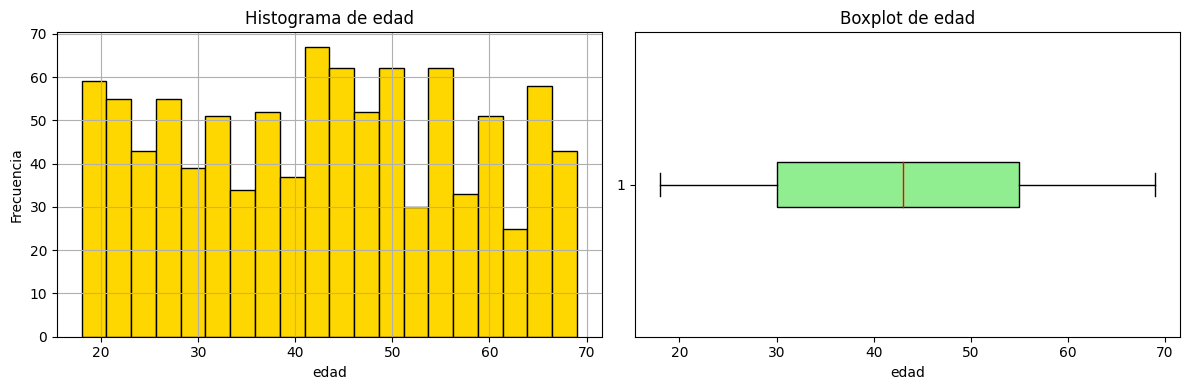

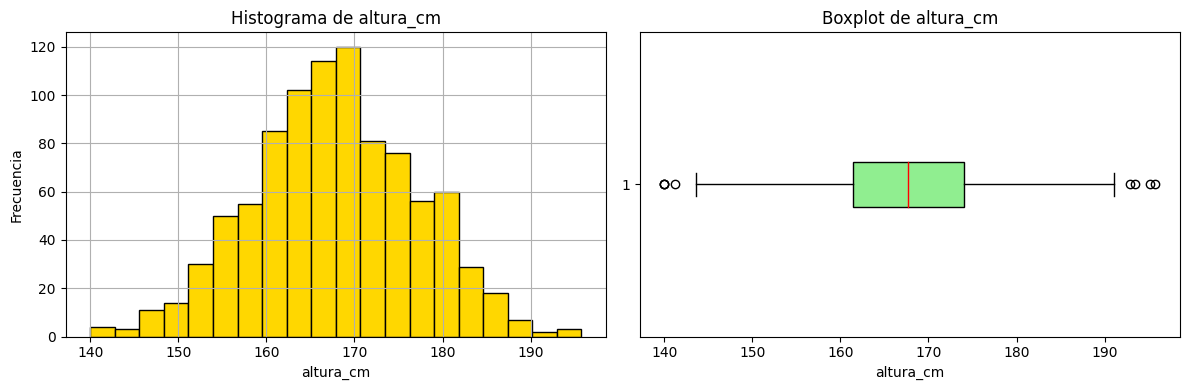

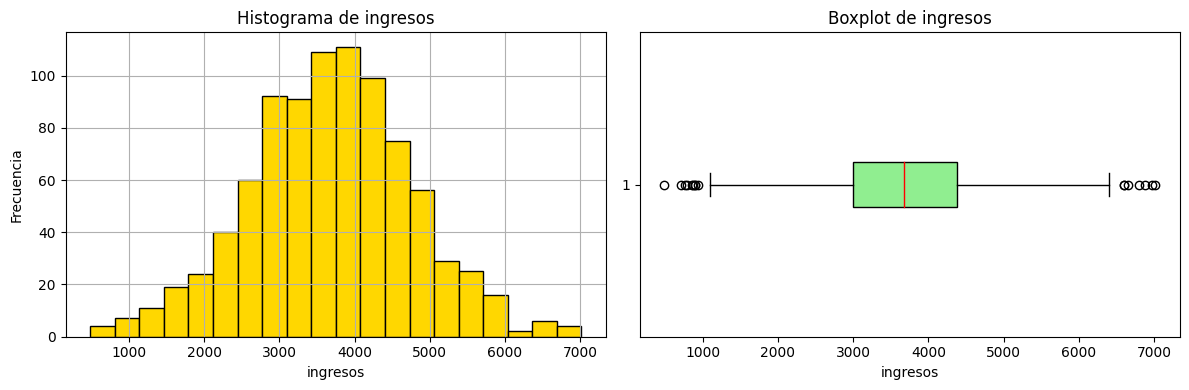

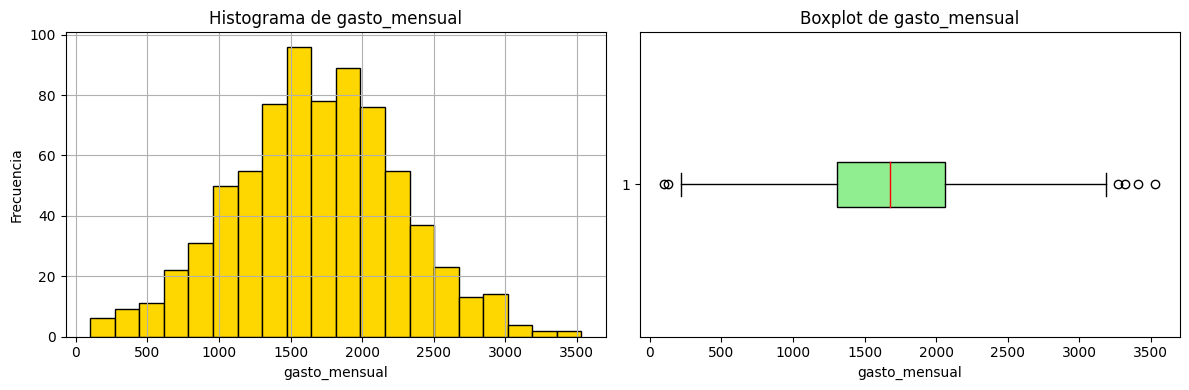

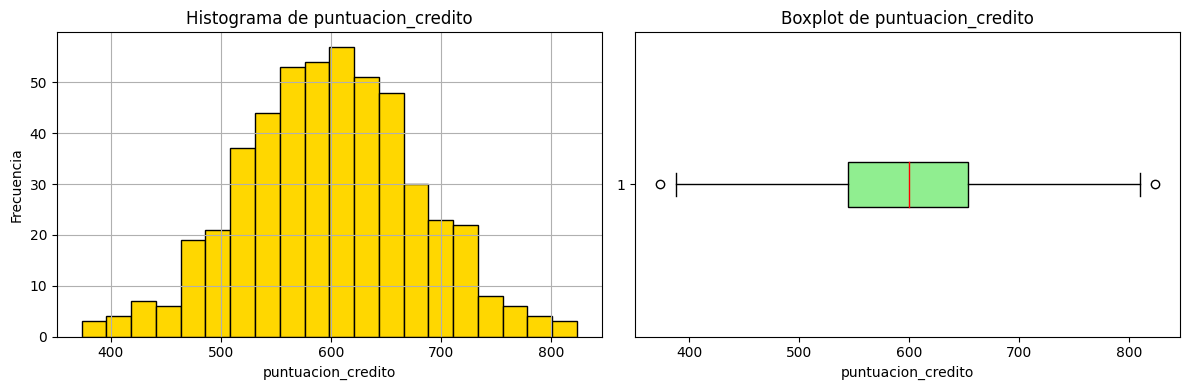

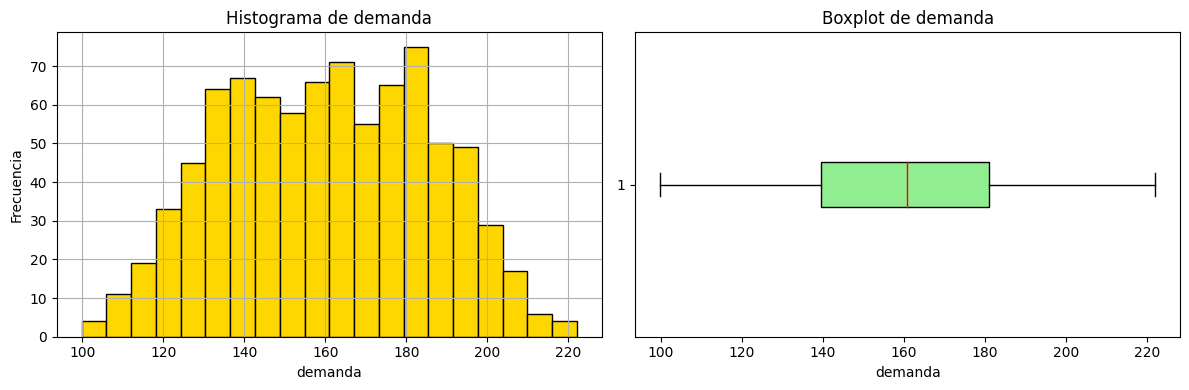

In [22]:
graficar_numericas(df)

Podemos observar que las variables de ingresos,altura_cm,gasto mensual y puntuacion de credito tienen outliers visibles. Aunque no se alejan de posibles valores reales. 

Tambien se observa que el histograma de ingresos y puntuacion de credito las distribuciones se asemejan a la forma de una normal

### Analisis categorico

como la variable fecha va a tener valores diferentes siempre debido a que es diaria no se tomara en cuenta para el analisis categorico

In [23]:
categoricas=['sexo','ciudad','nivel_educativo','segmento','estado_civil']

sexo
F    518
M    462
Name: count, dtype: int64


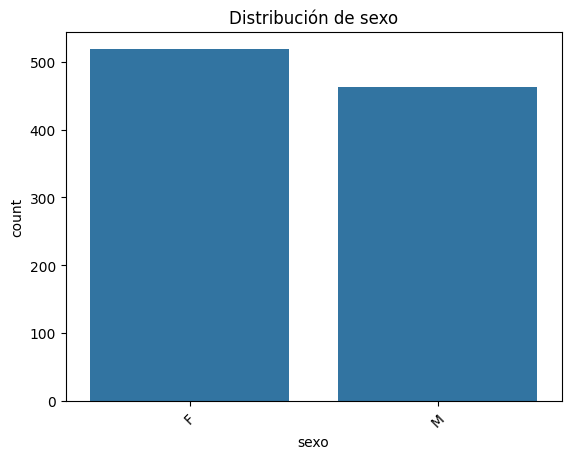

ciudad
Bogotá          307
Medellín        192
Cali            189
Barranquilla    161
Cartagena       101
Name: count, dtype: int64


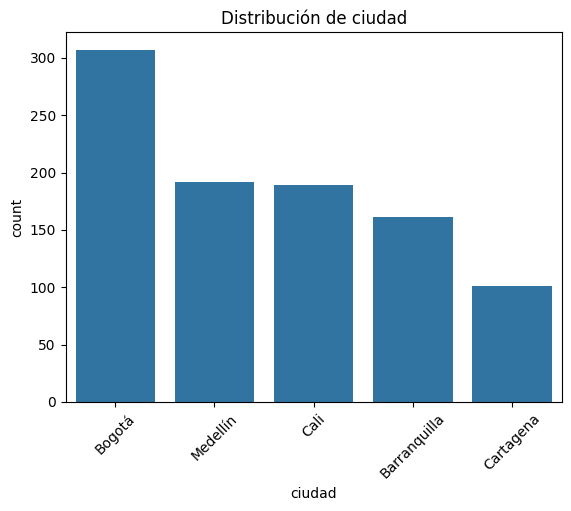

nivel_educativo
Secundaria       317
Universitario    251
Técnico          224
Posgrado         108
Name: count, dtype: int64


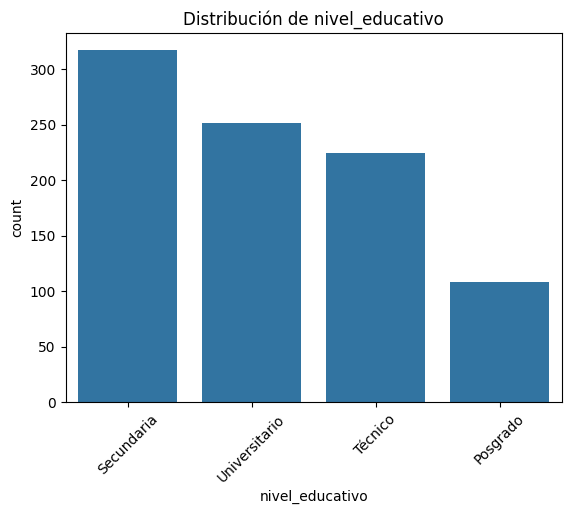

segmento
B    457
A    194
C    149
Name: count, dtype: int64


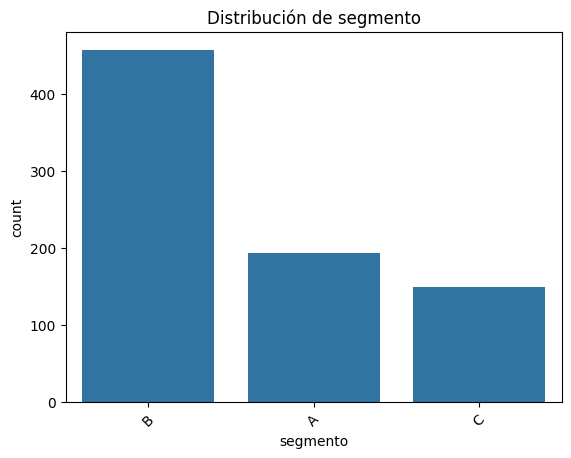

estado_civil
Soltero/a       290
Casado/a        231
Unión libre      93
Divorciado/a     36
Name: count, dtype: int64


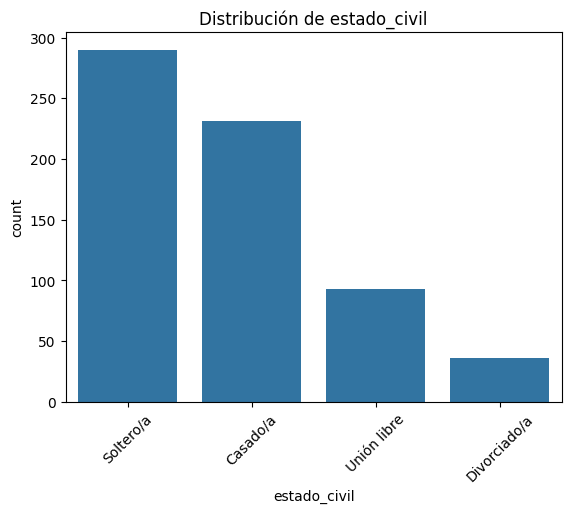

In [24]:
graficar_categoricas(df,categoricas)

Podemos observar que cada variable tiene pocas categorias en cada una, siendo las ciudades en las que mas tiene con 5. Podemos tambien observar que las observaciones estan bastante igualadas entre mujeres y hombres en el dataset a diferencia de las otras variables en las que una categoria es mas dominante que la otra

# Analisis Bivariado 

se realizo un analisis bivariado para determinar las relaciones entre las variables numericas 

Análisis entre: edad y altura_cm


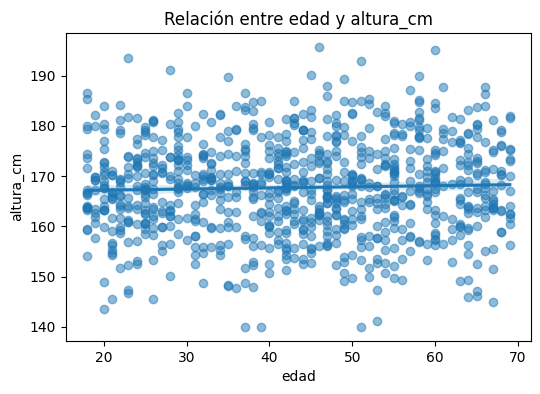

Shapiro edad: p=0.0000 -> No normal
Shapiro altura_cm: p=0.5915 -> Normal
Correlación (Spearman): 0.0344 (p-value=0.3044)

Análisis entre: edad y ingresos


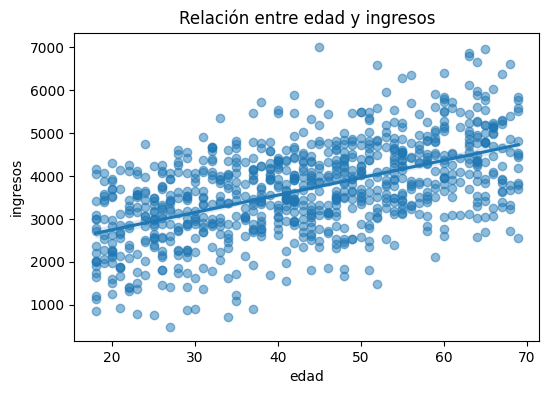

Shapiro edad: p=0.0000 -> No normal
Shapiro ingresos: p=0.3244 -> Normal
Correlación (Spearman): 0.5282 (p-value=0.0000)

Análisis entre: edad y gasto_mensual


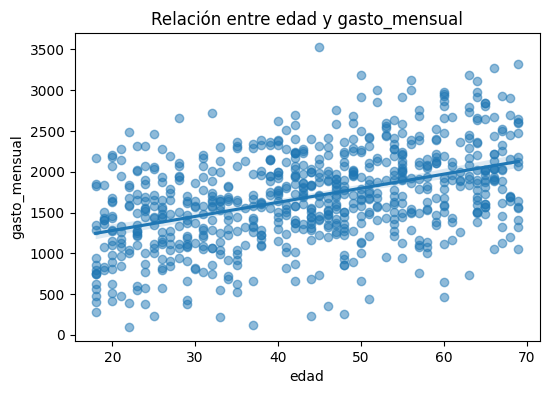

Shapiro edad: p=0.0000 -> No normal
Shapiro gasto_mensual: p=0.6746 -> Normal
Correlación (Spearman): 0.4214 (p-value=0.0000)

Análisis entre: edad y puntuacion_credito


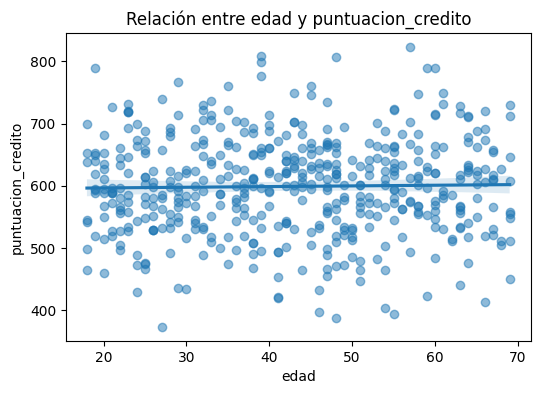

Shapiro edad: p=0.0000 -> No normal
Shapiro puntuacion_credito: p=0.9408 -> Normal
Correlación (Spearman): 0.0236 (p-value=0.6060)

Análisis entre: edad y demanda


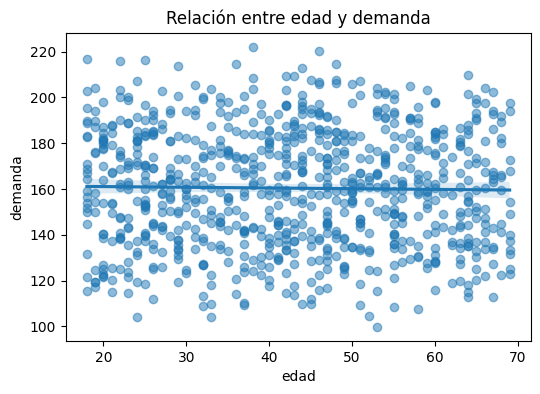

Shapiro edad: p=0.0000 -> No normal
Shapiro demanda: p=0.0000 -> No normal
Correlación (Spearman): -0.0167 (p-value=0.6325)

Análisis entre: altura_cm y ingresos


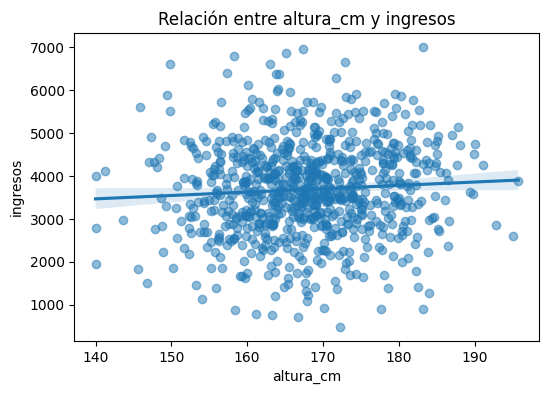

Shapiro altura_cm: p=0.5915 -> Normal
Shapiro ingresos: p=0.3244 -> Normal
Correlación (Pearson): 0.0670 (p-value=0.0564)

Análisis entre: altura_cm y gasto_mensual


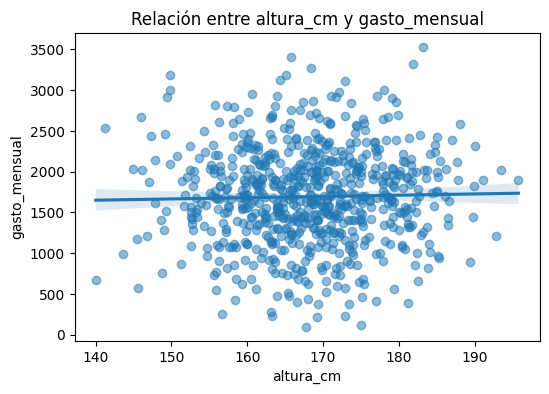

Shapiro altura_cm: p=0.5915 -> Normal
Shapiro gasto_mensual: p=0.6746 -> Normal
Correlación (Pearson): 0.0245 (p-value=0.5185)

Análisis entre: altura_cm y puntuacion_credito


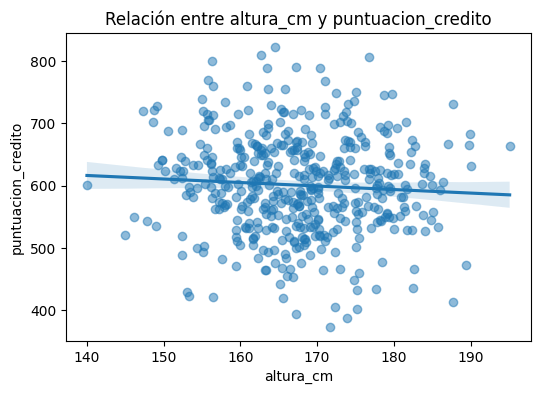

Shapiro altura_cm: p=0.5915 -> Normal
Shapiro puntuacion_credito: p=0.9408 -> Normal
Correlación (Pearson): -0.0659 (p-value=0.1597)

Análisis entre: altura_cm y demanda


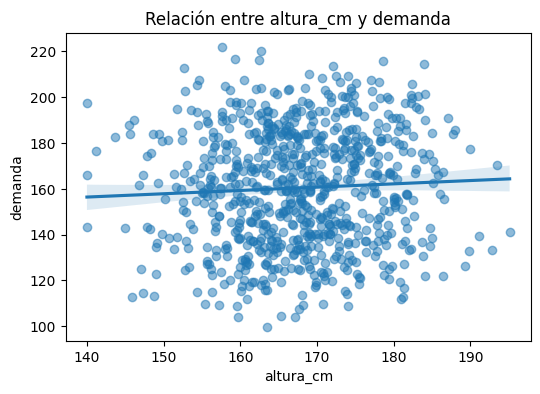

Shapiro altura_cm: p=0.5915 -> Normal
Shapiro demanda: p=0.0000 -> No normal
Correlación (Spearman): 0.0590 (p-value=0.0986)

Análisis entre: ingresos y gasto_mensual


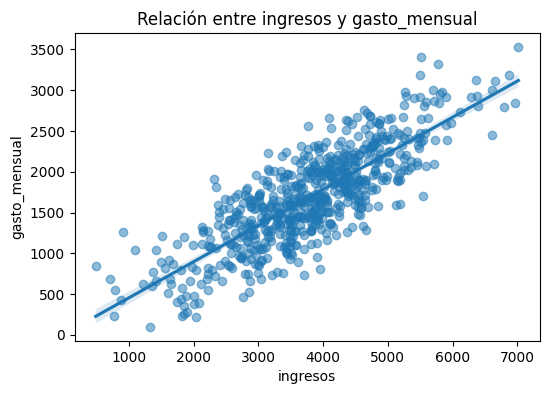

Shapiro ingresos: p=0.3244 -> Normal
Shapiro gasto_mensual: p=0.6746 -> Normal
Correlación (Pearson): 0.8134 (p-value=0.0000)

Análisis entre: ingresos y puntuacion_credito


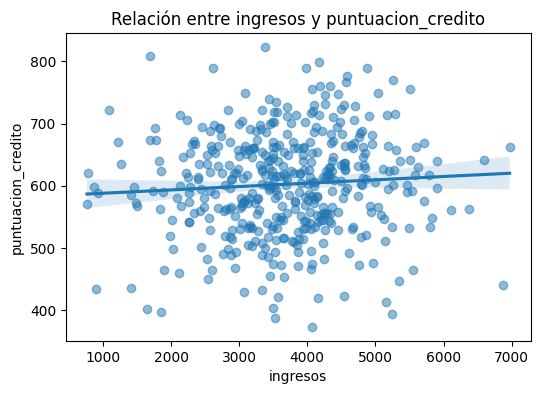

Shapiro ingresos: p=0.3244 -> Normal
Shapiro puntuacion_credito: p=0.9408 -> Normal
Correlación (Pearson): 0.0704 (p-value=0.1440)

Análisis entre: ingresos y demanda


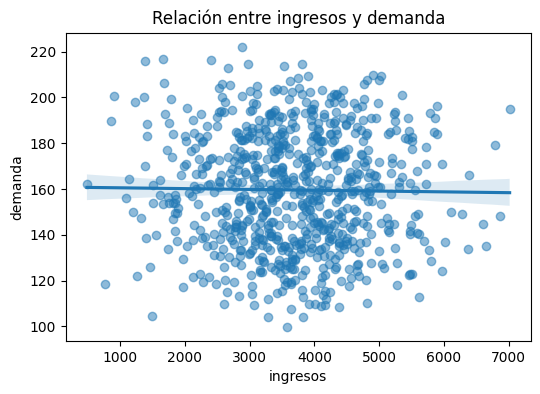

Shapiro ingresos: p=0.3244 -> Normal
Shapiro demanda: p=0.0000 -> No normal
Correlación (Spearman): -0.0073 (p-value=0.8411)

Análisis entre: gasto_mensual y puntuacion_credito


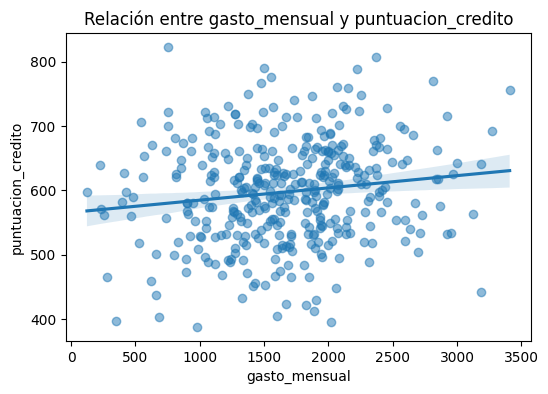

Shapiro gasto_mensual: p=0.6746 -> Normal
Shapiro puntuacion_credito: p=0.9408 -> Normal
Correlación (Pearson): 0.1413 (p-value=0.0061)

Análisis entre: gasto_mensual y demanda


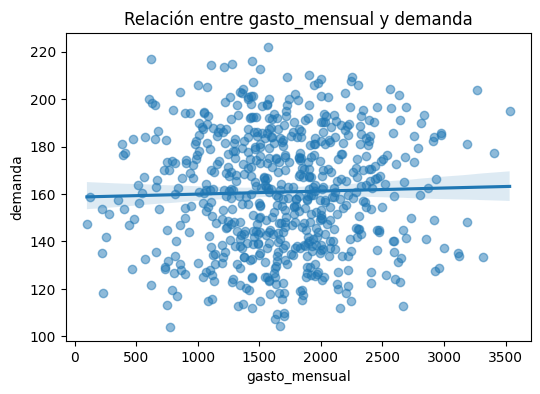

Shapiro gasto_mensual: p=0.6746 -> Normal
Shapiro demanda: p=0.0000 -> No normal
Correlación (Spearman): 0.0200 (p-value=0.6167)

Análisis entre: puntuacion_credito y demanda


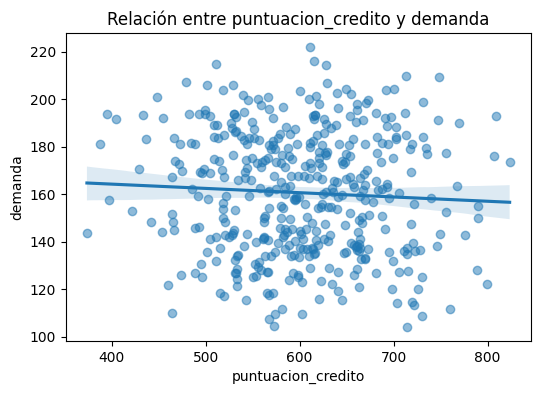

Shapiro puntuacion_credito: p=0.9408 -> Normal
Shapiro demanda: p=0.0000 -> No normal
Correlación (Spearman): -0.0492 (p-value=0.3146)



In [25]:
analisis_bivariado_todas_numericas(df)

Podemos observar que las variables mas relacionadas entre si son ingresos y el gasto mensual, siendo las que estan mas relacionadas entre si. La edad tambien se realciona entre estas 2 variables. Por lo que el nucleo de las correlaciones entre las numericas esta en las 3 variables. Las demas variables numericas no muestran correlaciones fuertes entre si

creamos la matriz de correlacion para las variables numericas, como la mayoria de relaciones son de tipo no normal se creara la matriz de correlacion de las variables numericas con spearman

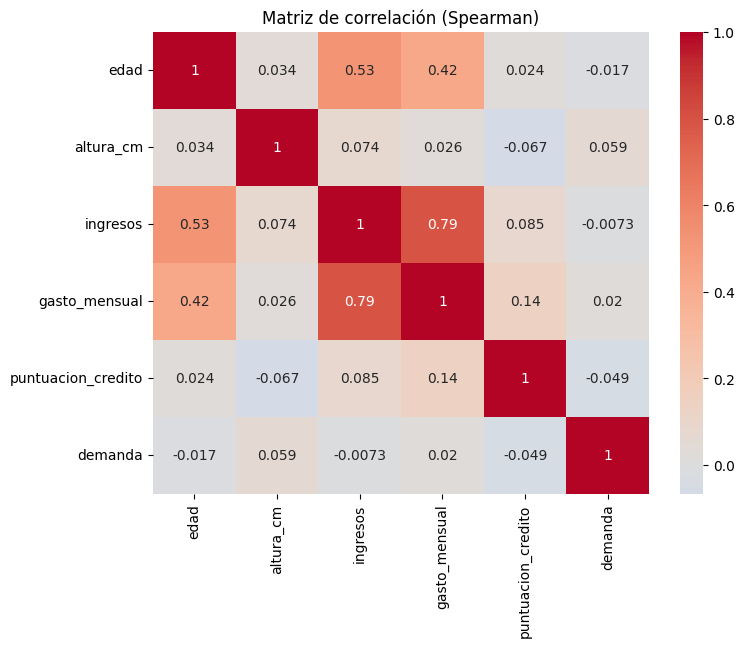

In [26]:
matriz_spearman(df)

realizamos el analisis bivariado para las variables categoricas

Análisis entre: sexo y ciudad

Tabla de contingencia:
ciudad  Barranquilla  Bogotá  Cali  Cartagena  Medellín
sexo                                                   
F                 77     159   113         50        95
M                 81     143    73         49        91


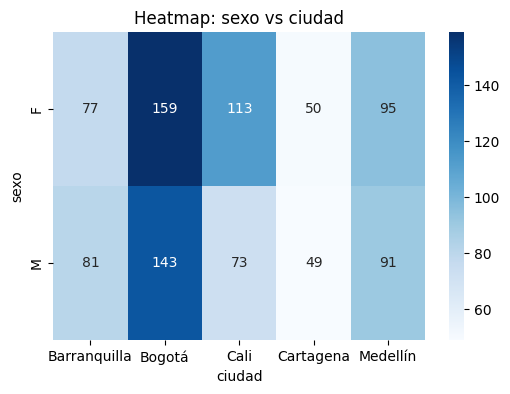


Chi-cuadrado: 6.1806, p-value=0.1861, grados libertad=4
Cramer's V: 0.0815

Análisis entre: sexo y nivel_educativo

Tabla de contingencia:
nivel_educativo  Posgrado  Secundaria  Técnico  Universitario
sexo                                                         
F                      62         153      131            123
M                      42         157       89            124


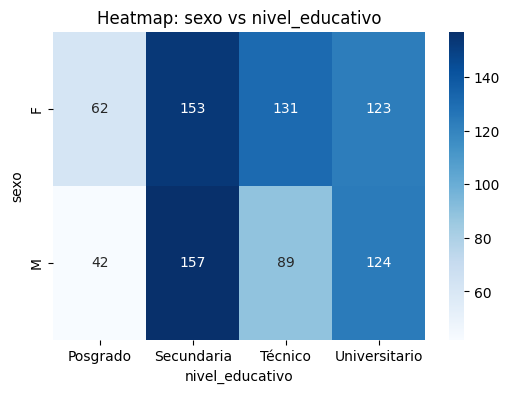


Chi-cuadrado: 8.2667, p-value=0.0408, grados libertad=3
Cramer's V: 0.0969

Análisis entre: sexo y segmento

Tabla de contingencia:
segmento    A    B   C
sexo                  
F         101  236  80
M          90  212  67


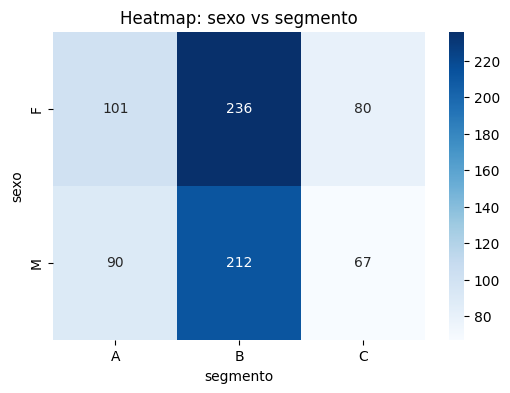


Chi-cuadrado: 0.1381, p-value=0.9333, grados libertad=2
Cramer's V: 0.0133

Análisis entre: sexo y estado_civil

Tabla de contingencia:
estado_civil  Casado/a  Divorciado/a  Soltero/a  Unión libre
sexo                                                        
F                  116            21        155           58
M                  110            15        129           34


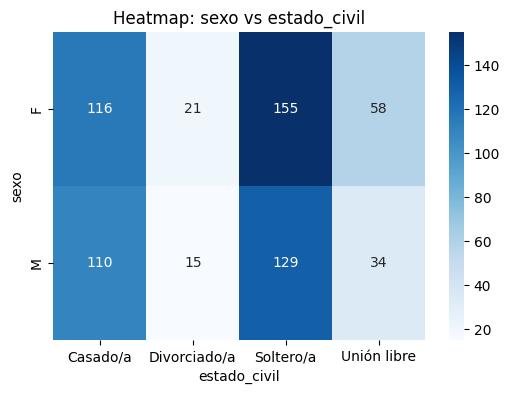


Chi-cuadrado: 3.8114, p-value=0.2826, grados libertad=3
Cramer's V: 0.0773

Análisis entre: ciudad y nivel_educativo

Tabla de contingencia:
nivel_educativo  Posgrado  Secundaria  Técnico  Universitario
ciudad                                                       
Barranquilla           13          50       39             42
Bogotá                 29          96       68             76
Cali                   22          56       41             52
Cartagena              15          31       26             23
Medellín               24          64       43             42


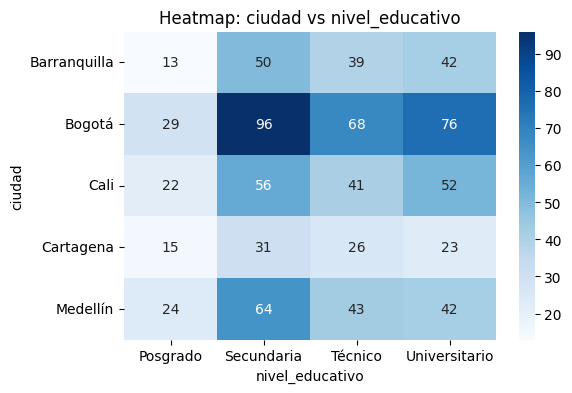


Chi-cuadrado: 5.9554, p-value=0.9183, grados libertad=12
Cramer's V: 0.0483

Análisis entre: ciudad y segmento

Tabla de contingencia:
segmento       A    B   C
ciudad                   
Barranquilla  31   80  24
Bogotá        54  138  51
Cali          41   85  27
Cartagena     19   47  12
Medellín      40   83  28


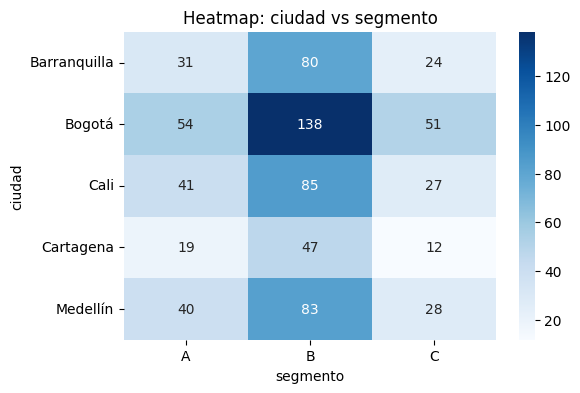


Chi-cuadrado: 2.9463, p-value=0.9377, grados libertad=8
Cramer's V: 0.0440

Análisis entre: ciudad y estado_civil

Tabla de contingencia:
estado_civil  Casado/a  Divorciado/a  Soltero/a  Unión libre
ciudad                                                      
Barranquilla        30             5         57           12
Bogotá              75            14         84           32
Cali                41             6         52           16
Cartagena           22             4         34            7
Medellín            51             6         50           18


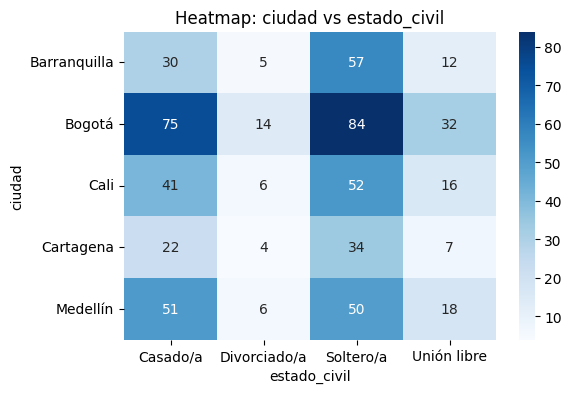


Chi-cuadrado: 8.9266, p-value=0.7092, grados libertad=12
Cramer's V: 0.0695

Análisis entre: nivel_educativo y segmento

Tabla de contingencia:
segmento          A    B   C
nivel_educativo             
Posgrado         17   50  18
Secundaria       55  158  39
Técnico          40  111  34
Universitario    57   98  42


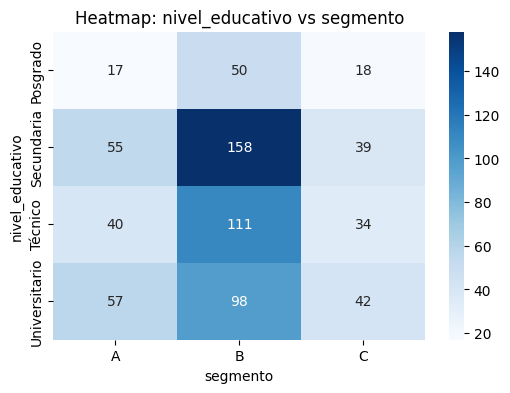


Chi-cuadrado: 9.3300, p-value=0.1559, grados libertad=6
Cramer's V: 0.0805

Análisis entre: nivel_educativo y estado_civil

Tabla de contingencia:
estado_civil     Casado/a  Divorciado/a  Soltero/a  Unión libre
nivel_educativo                                                
Posgrado               27             4         28           16
Secundaria             70            13         95           30
Técnico                58             7         60           16
Universitario          61            10         77           22


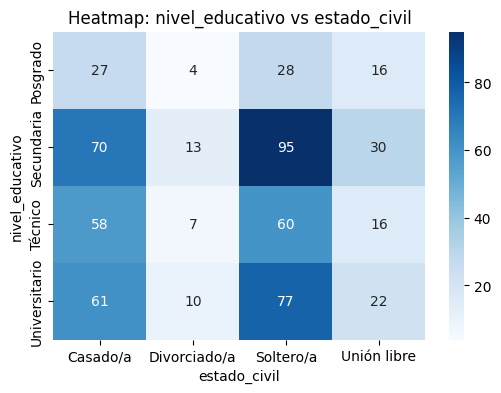


Chi-cuadrado: 6.3126, p-value=0.7083, grados libertad=9
Cramer's V: 0.0595

Análisis entre: segmento y estado_civil

Tabla de contingencia:
estado_civil  Casado/a  Divorciado/a  Soltero/a  Unión libre
segmento                                                    
A                   42             8         61           18
B                  103            15        134           50
C                   43             4         39            9


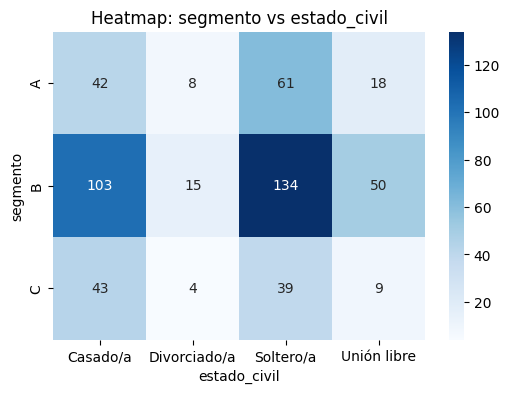


Chi-cuadrado: 6.4736, p-value=0.3723, grados libertad=6
Cramer's V: 0.0784



In [27]:
analisis_bivariado_categoricas(df)

Podemos analizar que la mayoria de variables tienen p-valores mas grandes que 0.05 siendo sexo-nivel_educativo, aunque debido  su valor bajo en la matriz de cramer las diferencias existen pero no seran determinantes. Debido a esto no hay evidencias que las variables categoricas se relacionen de manera fuerte entre si, a excepcion de sexo-nivel educativo, que aunque su relacion sea debil merece ser tomada en cuenta para los analisis posteriores

realizamos el analisis bivariado entre categoricas y numericas


=== Análisis entre sexo (categórica) y edad (numérica) ===



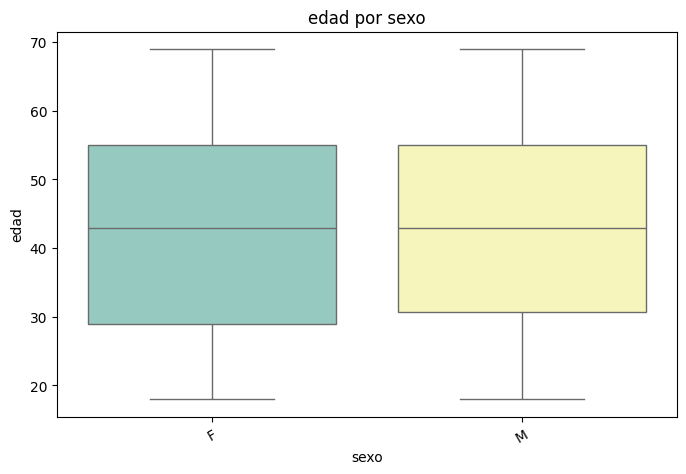


=== Análisis entre sexo (categórica) y altura_cm (numérica) ===



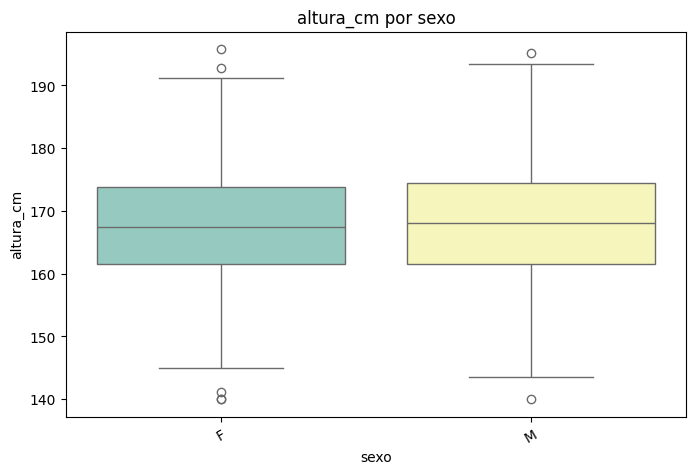


=== Análisis entre sexo (categórica) y ingresos (numérica) ===



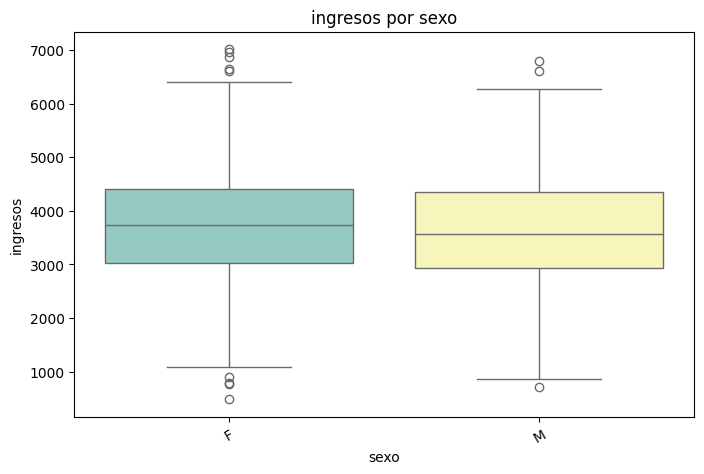


=== Análisis entre sexo (categórica) y gasto_mensual (numérica) ===



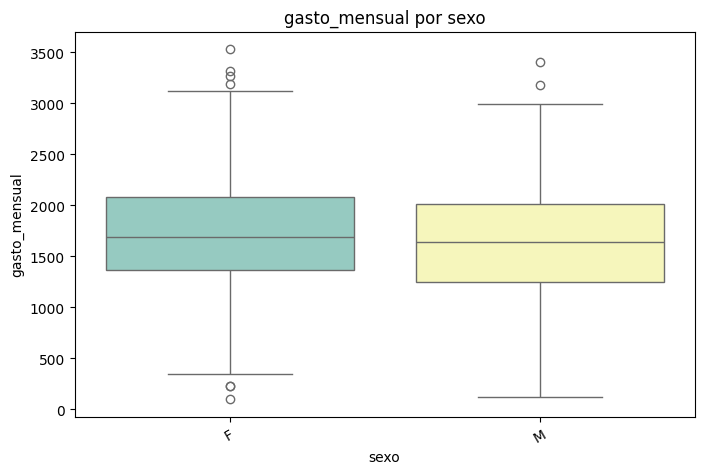


=== Análisis entre sexo (categórica) y puntuacion_credito (numérica) ===



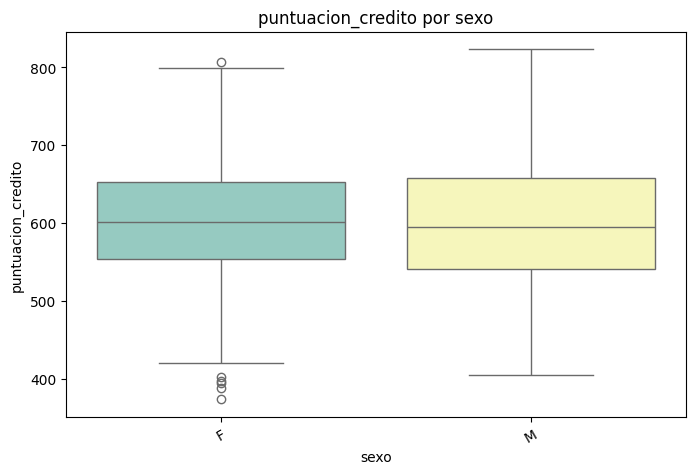


=== Análisis entre sexo (categórica) y demanda (numérica) ===



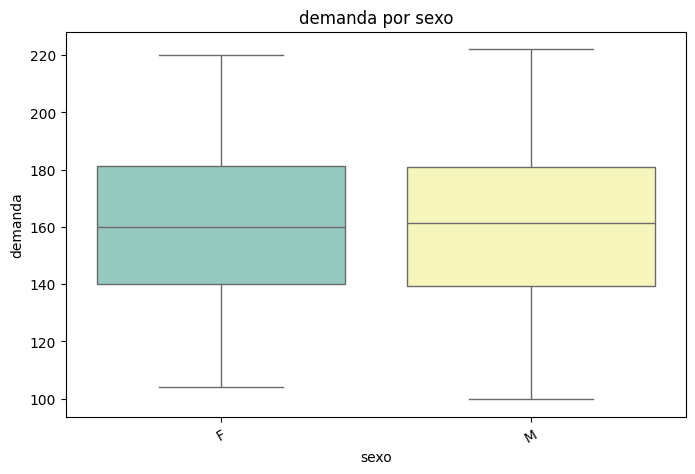


=== Análisis entre ciudad (categórica) y edad (numérica) ===



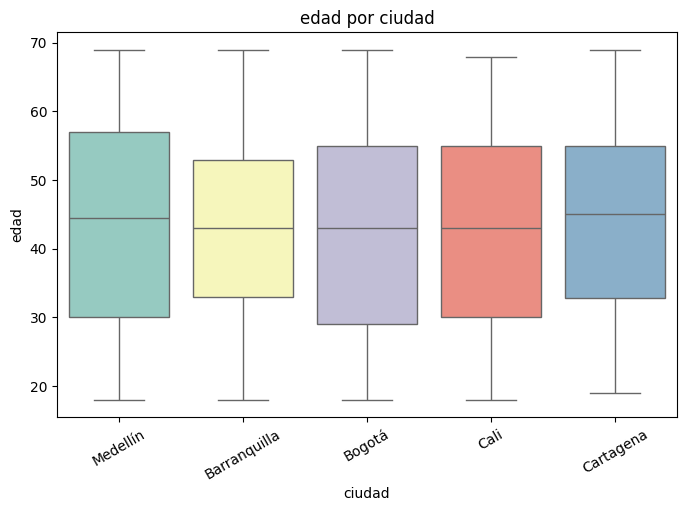


=== Análisis entre ciudad (categórica) y altura_cm (numérica) ===



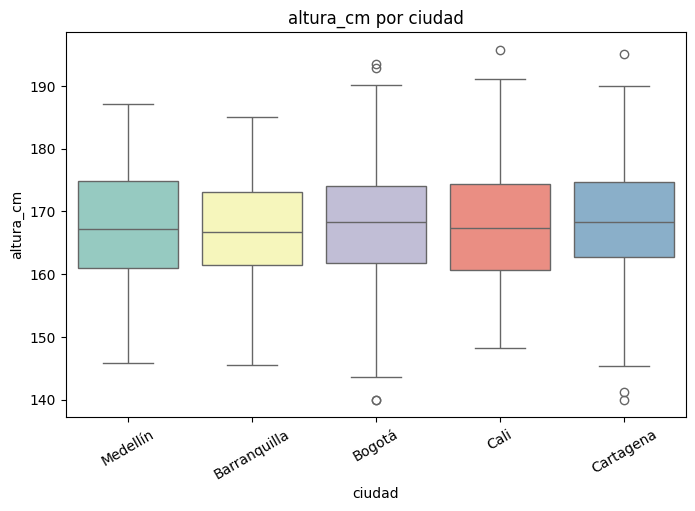


=== Análisis entre ciudad (categórica) y ingresos (numérica) ===



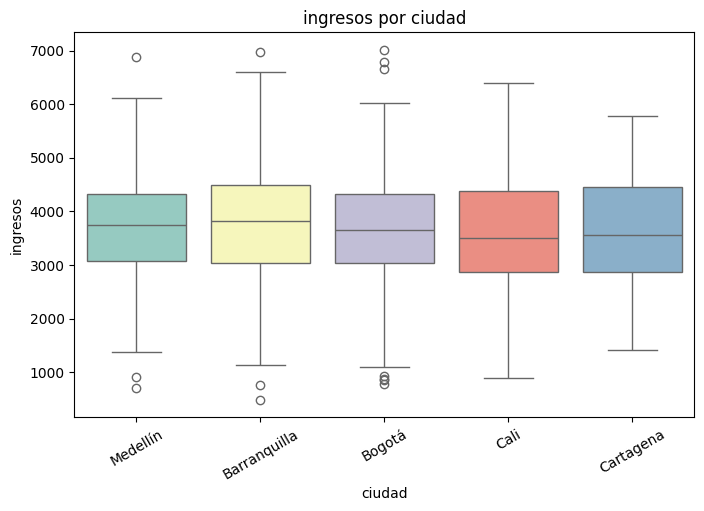


=== Análisis entre ciudad (categórica) y gasto_mensual (numérica) ===



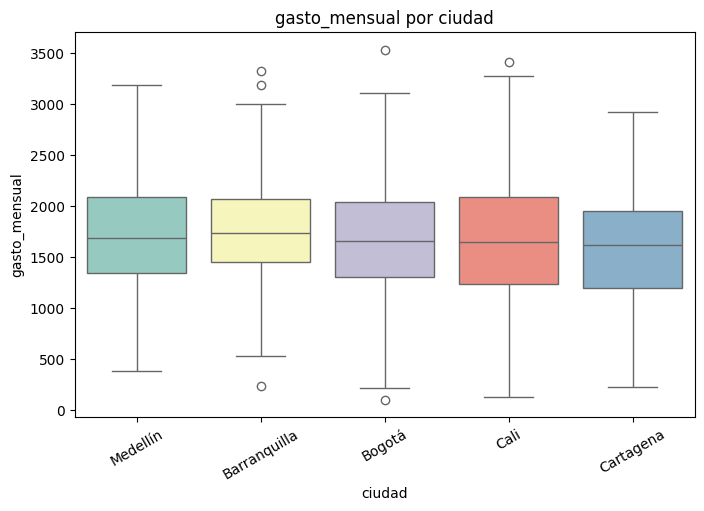


=== Análisis entre ciudad (categórica) y puntuacion_credito (numérica) ===



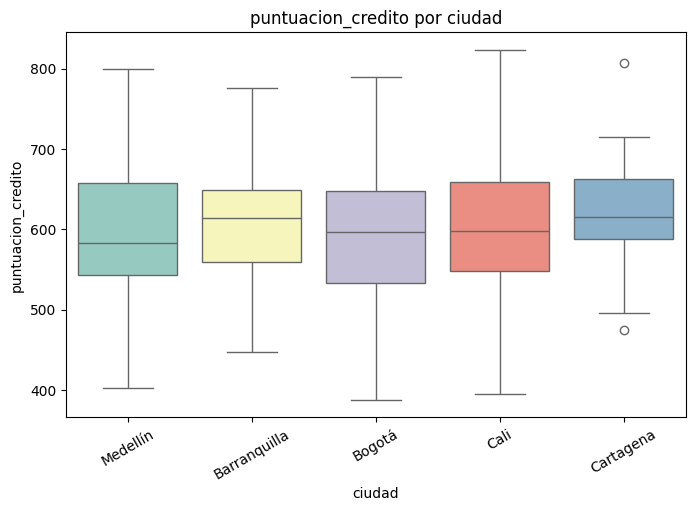


=== Análisis entre ciudad (categórica) y demanda (numérica) ===



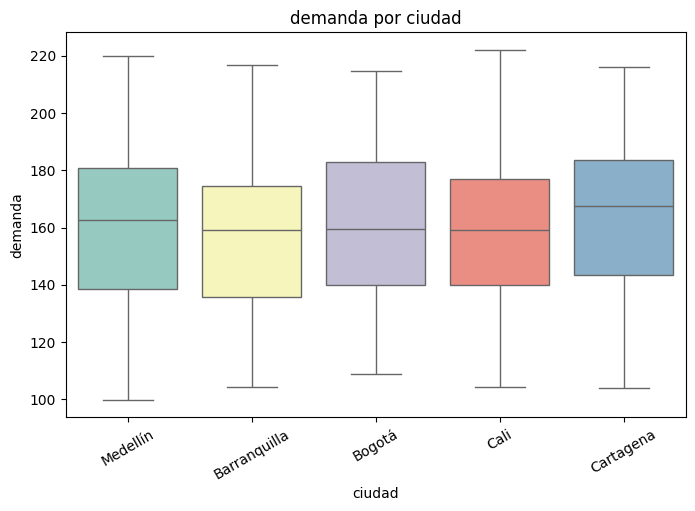


=== Análisis entre nivel_educativo (categórica) y edad (numérica) ===



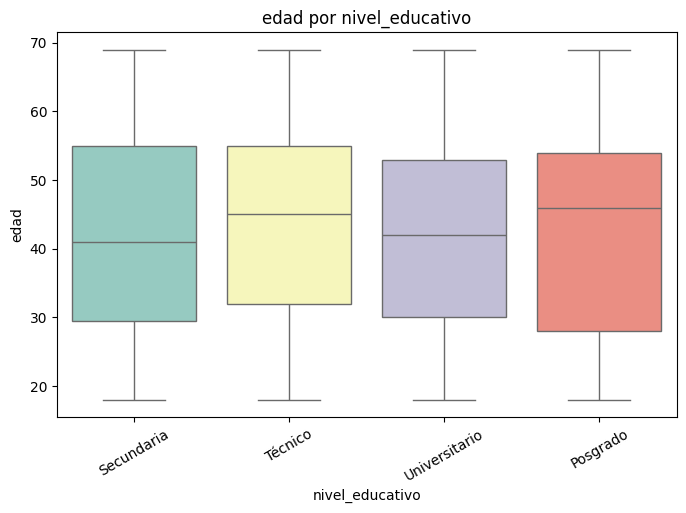


=== Análisis entre nivel_educativo (categórica) y altura_cm (numérica) ===



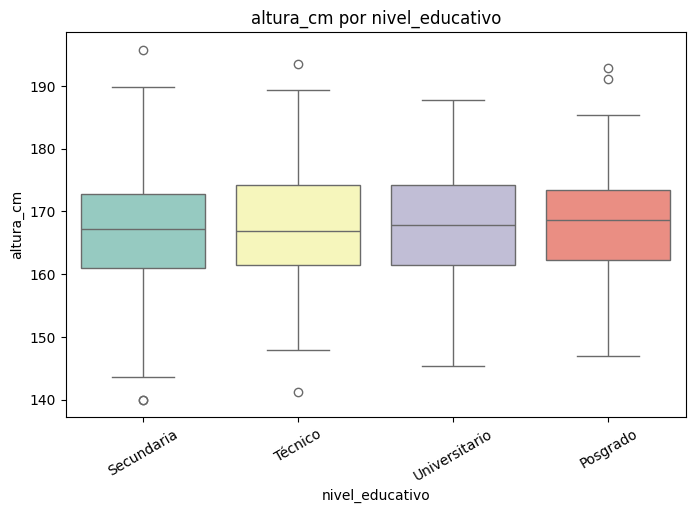


=== Análisis entre nivel_educativo (categórica) y ingresos (numérica) ===



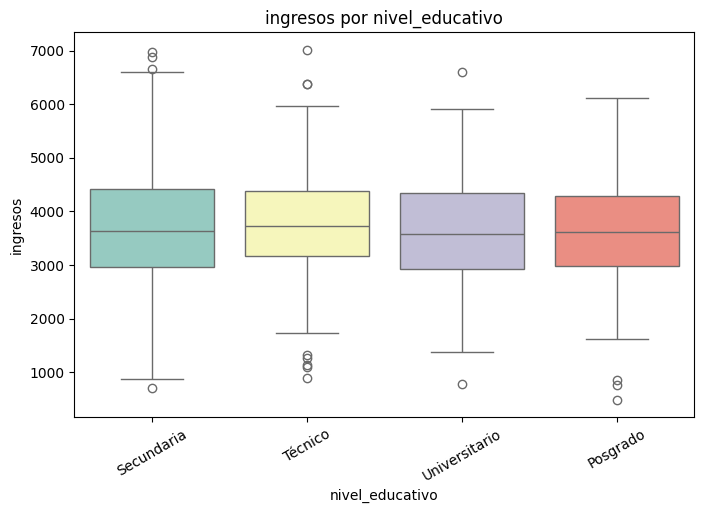


=== Análisis entre nivel_educativo (categórica) y gasto_mensual (numérica) ===



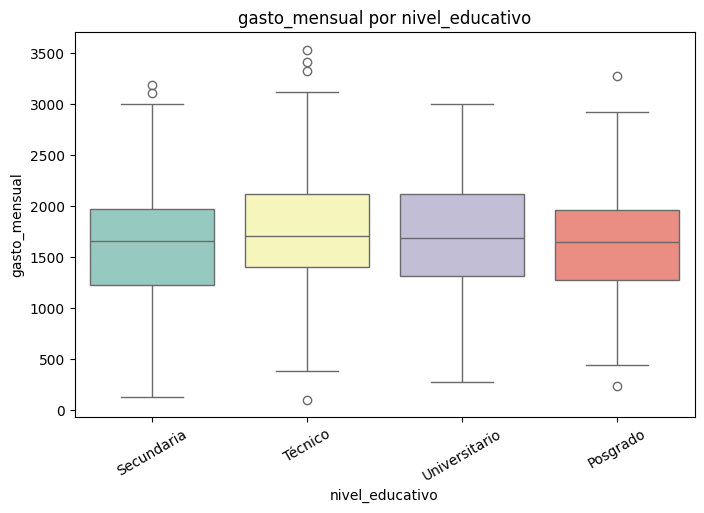


=== Análisis entre nivel_educativo (categórica) y puntuacion_credito (numérica) ===



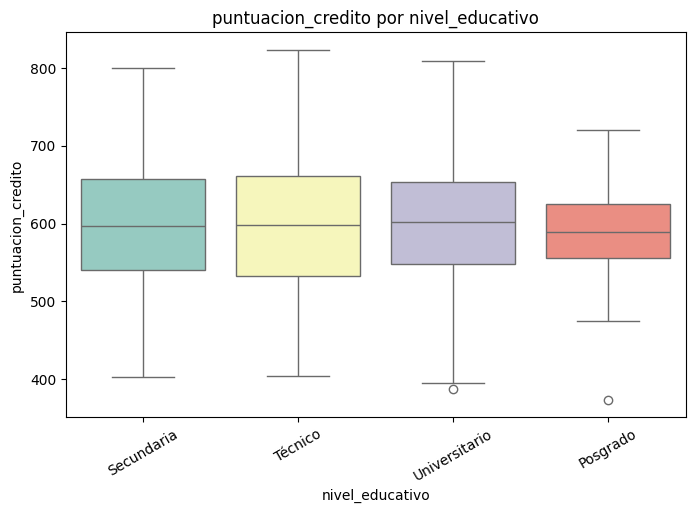


=== Análisis entre nivel_educativo (categórica) y demanda (numérica) ===



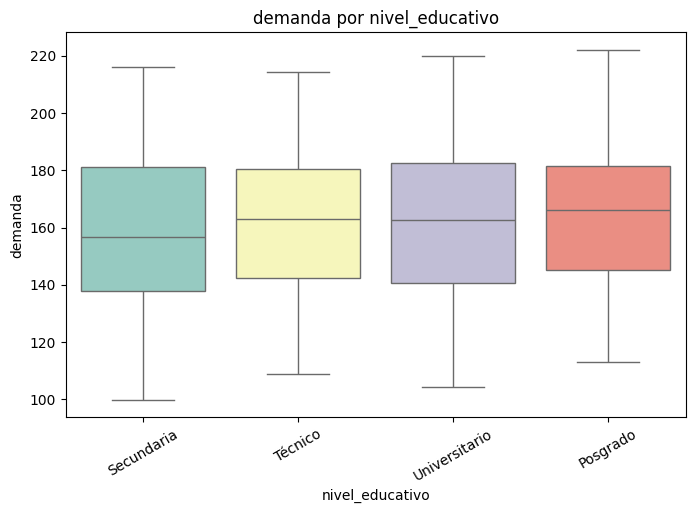


=== Análisis entre segmento (categórica) y edad (numérica) ===



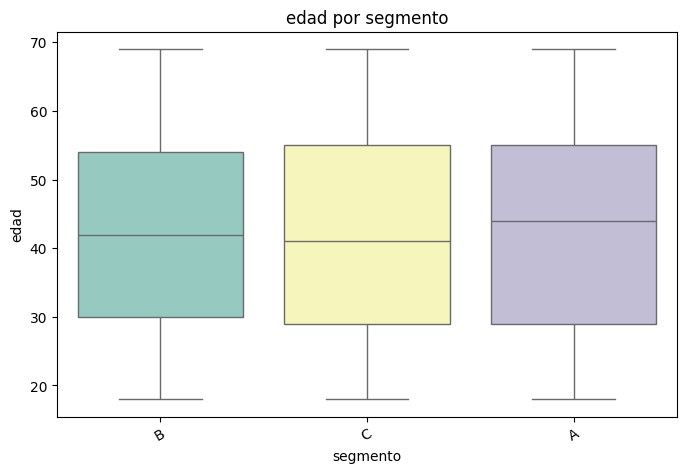


=== Análisis entre segmento (categórica) y altura_cm (numérica) ===



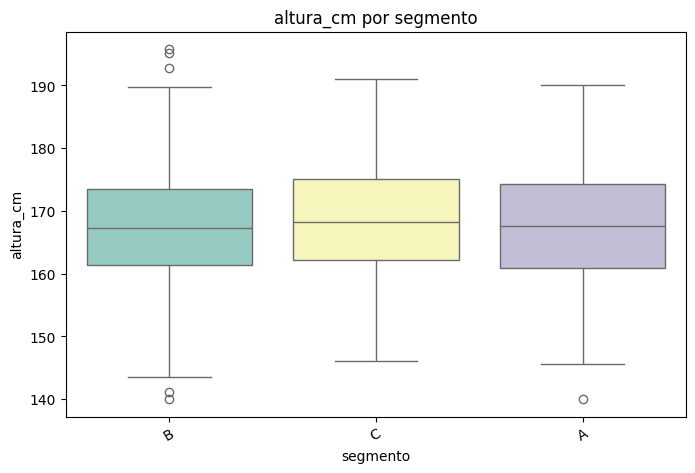


=== Análisis entre segmento (categórica) y ingresos (numérica) ===



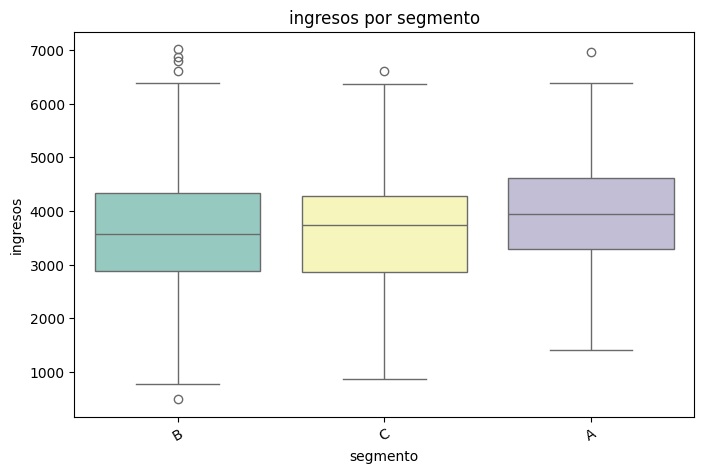


=== Análisis entre segmento (categórica) y gasto_mensual (numérica) ===



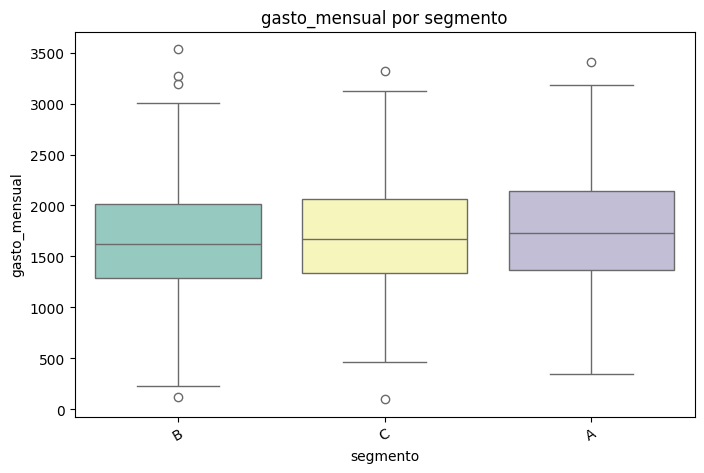


=== Análisis entre segmento (categórica) y puntuacion_credito (numérica) ===



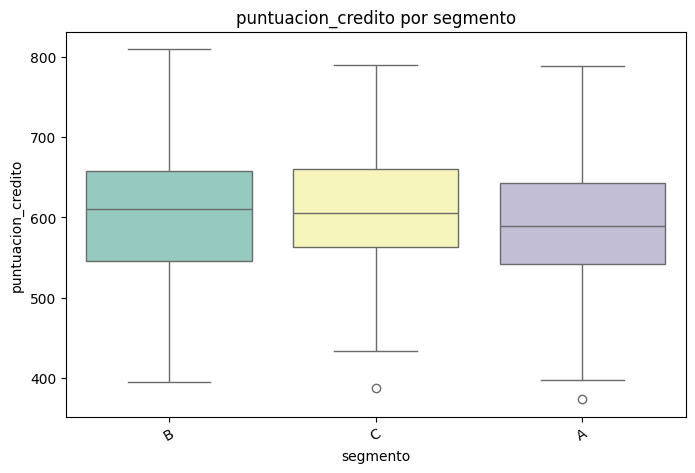


=== Análisis entre segmento (categórica) y demanda (numérica) ===



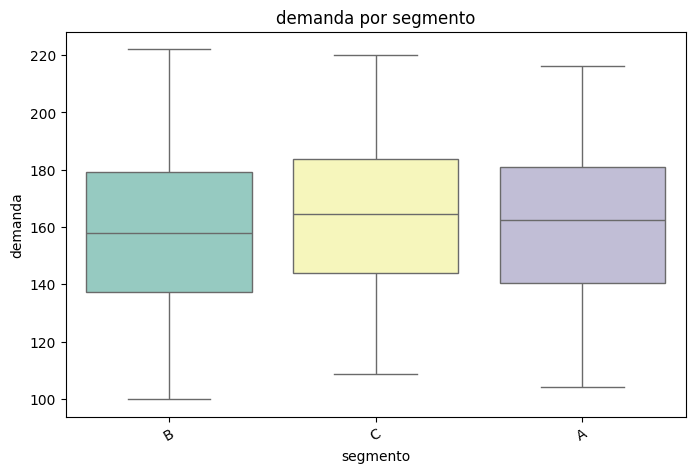


=== Análisis entre estado_civil (categórica) y edad (numérica) ===



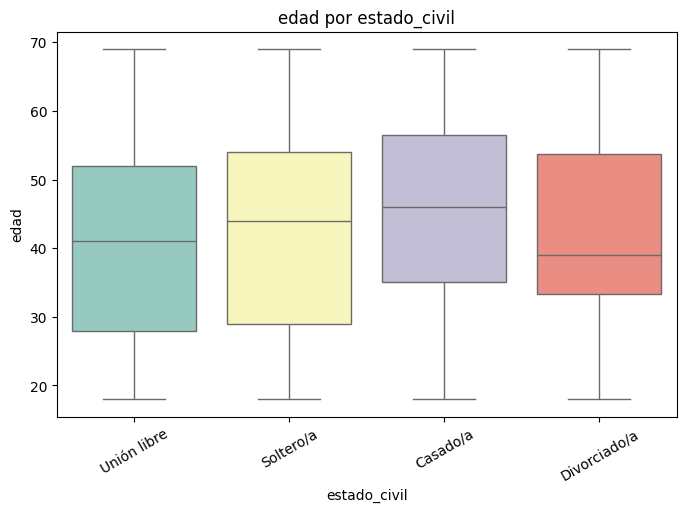


=== Análisis entre estado_civil (categórica) y altura_cm (numérica) ===



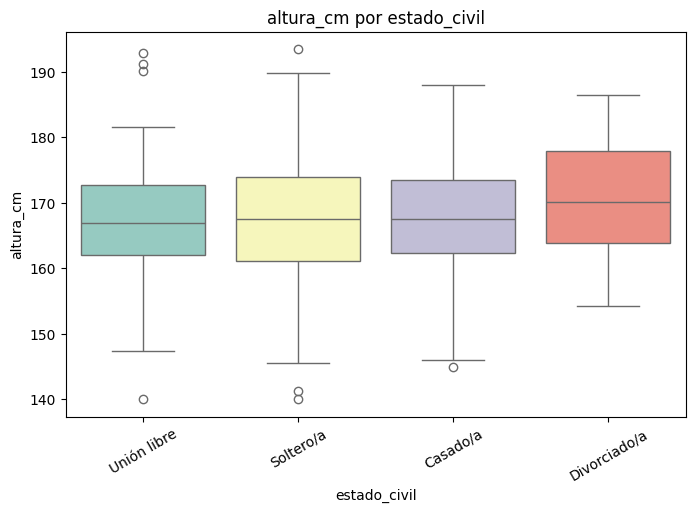


=== Análisis entre estado_civil (categórica) y ingresos (numérica) ===



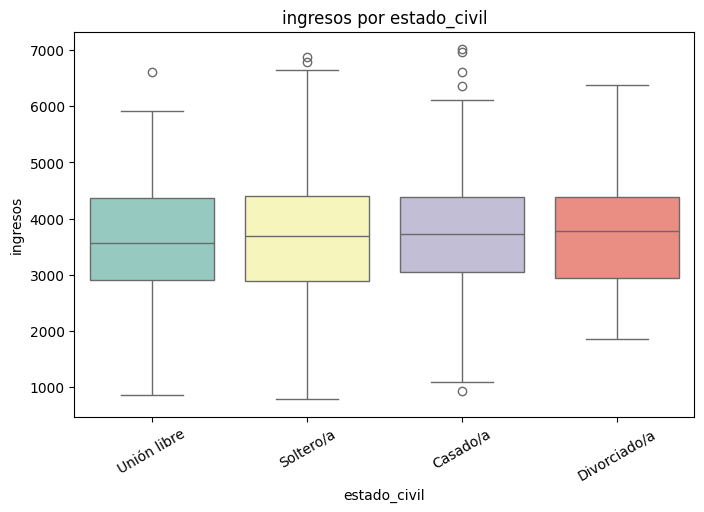


=== Análisis entre estado_civil (categórica) y gasto_mensual (numérica) ===



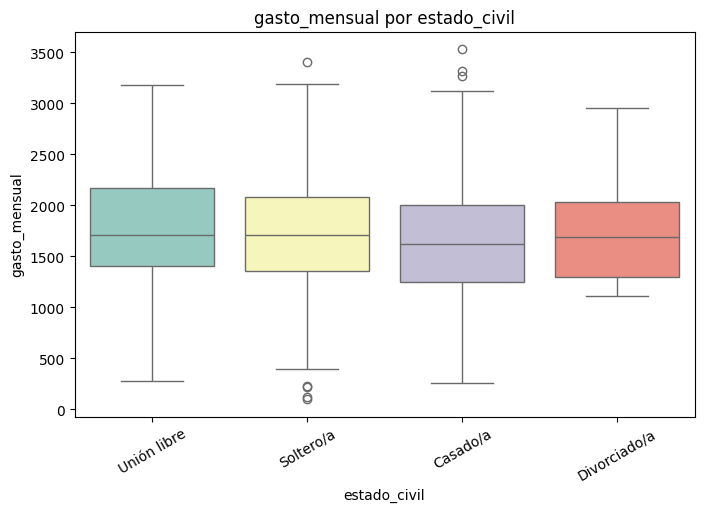


=== Análisis entre estado_civil (categórica) y puntuacion_credito (numérica) ===



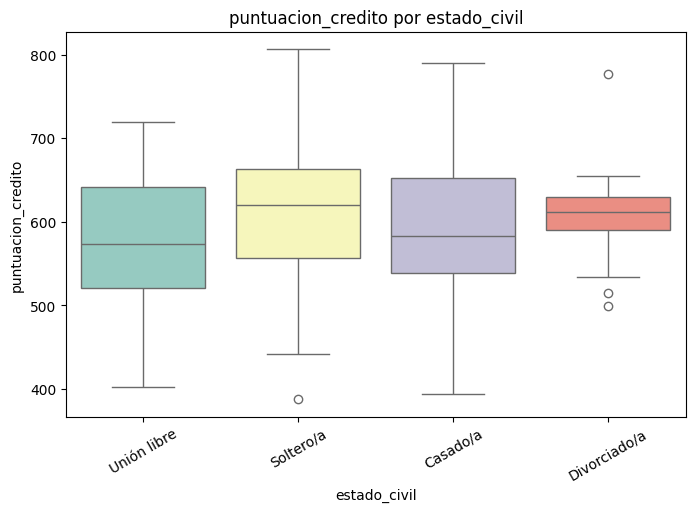


=== Análisis entre estado_civil (categórica) y demanda (numérica) ===



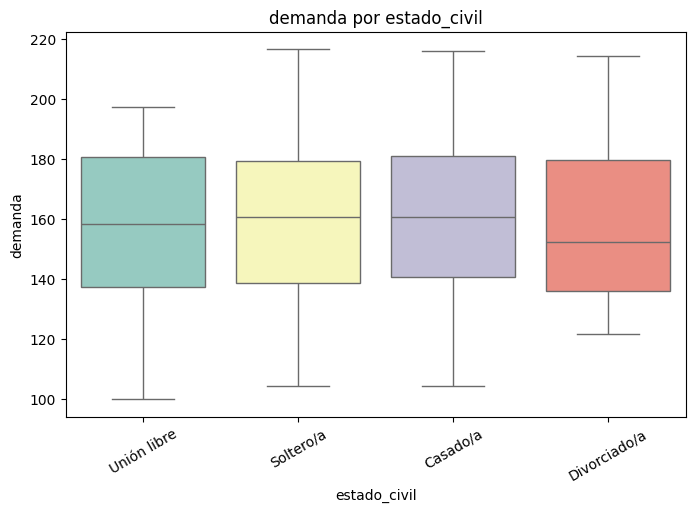

,Categorica,Numerica,Prueba,Estadístico,p-value
0,sexo,edad,Kruskal-Wallis,0.390618,0.531975
1,sexo,altura_cm,ANOVA,1.213307,0.270973
2,sexo,ingresos,ANOVA,0.670721,0.413027
3,sexo,gasto_mensual,ANOVA,2.882864,0.089952
4,sexo,puntuacion_credito,ANOVA,0.024374,0.876002
5,sexo,demanda,Kruskal-Wallis,0.002729,0.958339
6,ciudad,edad,Kruskal-Wallis,1.623363,0.804587
7,ciudad,altura_cm,ANOVA,0.558467,0.692889
8,ciudad,ingresos,ANOVA,0.509376,0.728870
9,ciudad,gasto_mensual,ANOVA,1.071772,0.369408


In [28]:
bivariado_cat_num_all(df)

Podemos observar que en la mayoria de variables numericas no existe una asociacion estadisticamente significativa entre las variables del dataset, la unica relacion cuyo p-valor es menor que 0.05 y si es estadisticamente significativa es la de segmento e ingresos . Esto implica que el nivel de ingresos varía de manera importante entre los diferentes segmentos

# Deteccion de valores faltantes

Revisamos el porcentaje de nulos que tiene cada variable 

In [29]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

print("=== Resumen de valores nulos ===")
print(missing_summary)

=== Resumen de valores nulos ===
                    Nulos  Porcentaje (%)
sexo                   20             2.0
ciudad                 50             5.0
nivel_educativo       100            10.0
segmento              200            20.0
estado_civil          350            35.0
edad                   30             3.0
altura_cm              80             8.0
ingresos              120            12.0
gasto_mensual         250            25.0
puntuacion_credito    500            50.0
demanda               150            15.0


realizamos la grafica de los valores nulos utilizando un barplot y un heatmap

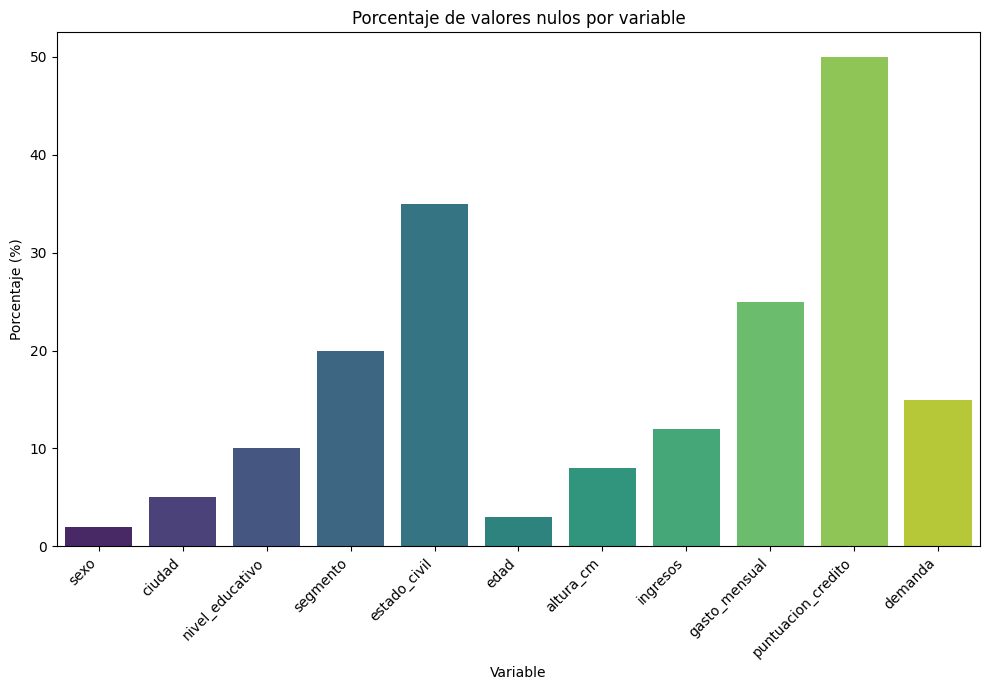

In [30]:
plt.figure(figsize=(10,7))
sns.barplot(x=missing_summary.index, y=missing_summary["Porcentaje (%)"], palette="viridis")
plt.title("Porcentaje de valores nulos por variable")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

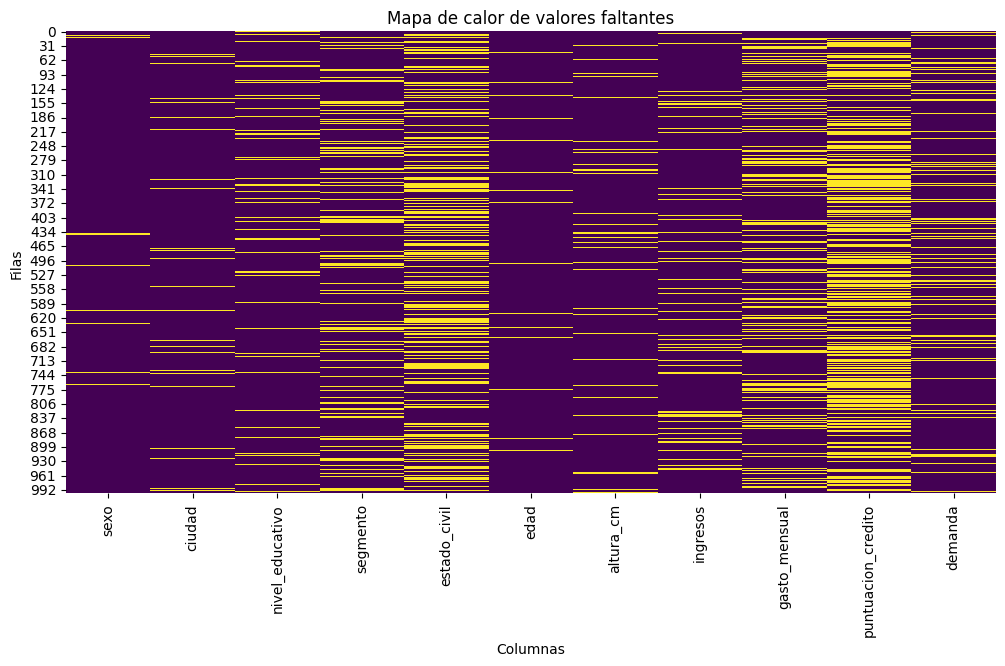

In [31]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de calor de valores faltantes")
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.show()

Podemos observar que la puntuacion de credito es la variable que mas tiene NA con un 50% de faltantes y otras 3 variables tambien tienen valores mayores al 20%. Estas variables se analizaran con mas cuidado mas adelante para determinar si se pueden imputar o no

# Clasificacion de faltantes 

Con los patrones observados en el EDA, se van a clasificar los tipos de datos faltantes de cada una de las variables y una breve explicacion del porque estan en cada categoria


**MCAR**: edad, altura_cm, segmento, demanda,sexo,ciudad

Explicacion: estas variables no tienen una relacion muy significativa con el resto de las variables y son las que sus NA mas pueden deberse debido al azar  

**MAR**: ingresos, saldo mensual, nivel educativo

Explicacion: estas variables son las que tienen una relacion mas significativa con respecto a las otras variables por lo que hay que tomar eso en cuenta a la hora de imputar 

**MNAR**: puntuacion de credito, estado civil

Explicacion: estas son las variables con la mayor cantidad de NA, ademas no tienen una relacion fuerte con las otras variables y son las mas probables de tener valores faltantes porque no fueron observados. Imputar estas variables no seria tan seguro si se hace directamente

# Discusion de imputabilidad 

Se analizara variable por variable para determinar cual seria el mejor metodo de imputacion a realizar para cada uno

**Sexo**: 
- Tiene bajo porcentaje de NA(2%)
- sus faltantes son aleatorios(MCAR)
- la variable es categorica

Metodo de imputacion: Moda

**Ciudad**
- bajo porcentaje de NA(5%)
- sus faltantes son aleatorios(MCAR)
- La variable es categorica 

Metodo de imputacion: Hot-deck

**Nivel educativo**
- porcentaje de NA(10%)
- sus faltantes estan relacionados con otras variables 
- La variable es categorica 

Metodo de imputacion: Hot-deck

**Segmento**
- porcentaje de NA(20%)
- datos faltantes aleatorios 
- La variable es categorica 

Metodo de imputacion: KNN 

**Estado civil**
- porcentaje de NA(35%)
- datos faltantes tipo MNAR
- La variable es categorica 

Metodo de imputacion: no se imputa directamente, tratamos los faltantes como categoria "missing"

**Edad**
-  bajo porcentaje de NA(3%)
- datos faltantes aleatorios 
- La variable es numerica

Metodo de imputacion: Mediana(variable no normal)

**Altura_cm**
-  bajo porcentaje de NA(8%)
- datos faltantes aleatorios 
- La variable es numerica

Metodo de imputacion: Mediana

**Ingresos**
-  porcentaje de NA(12%)
- datos faltantes relacionados con otras variables
- La variable es numerica

Metodo de imputacion: Regresion o KNN

**Gasto_mensual**
-  porcentaje de NA(25%)
- datos faltantes relacionados con otras variables
- La variable es numerica

Metodo de imputacion: KNN o MICE

**Puntuacion_credito**
- porcentaje de NA(50%)
- datos faltantes tipo MNAR
- La variable es numerica 

Metodo de imputacion: no se imputa directamente, tratamos los faltantes como categoria "missing"

**Demanda**
- porcentaje de NA(15%)
- datos faltantes aleatorios
- La variable es numerica 

Metodo de imputacion: KNN  

#  Representacion de la Imputacion

Antes de elegir el metodo de imputacion se van a evaluar la normalidad de las variables numericas 

In [32]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
1,altura_cm,920,5.915049e-01,7.946680e-01,0.725425,True
2,ingresos,880,3.243902e-01,6.173557e-01,0.899760,True
3,gasto_mensual,750,6.746288e-01,8.791065e-01,0.961382,True
4,puntuacion_credito,500,9.408124e-01,9.651871e-01,0.997282,True
0,edad,970,1.133051e-15,9.628678e-93,0.000063,False
5,demanda,850,1.129299e-07,1.958694e-19,0.025404,False


Podemos analizar que la variable edad y la variable demanda no siguen una distribucion normal a diferencia del resto de variables que si siguen normalidad. Esto se tomara en cuenta mas adelante a la hora de revisar si hubo cambio en la distribucion despues de imputar. A pesar de que la variable altura si es normal se imputara con la mediana porque es mas robusta a la hora de realizar imputacion simple 

## Imputacion por  Mediana

In [33]:
imp_median = SimpleImputer(strategy="median")
df_mediana = df.copy()
df_mediana[["edad",'altura_cm']] = imp_median.fit_transform(df_mediana[["edad",'altura_cm']])

print("\n Datos imputados con la MEDIANA")
print(df_mediana.head(10))


 Datos imputados con la MEDIANA
  sexo        ciudad nivel_educativo segmento estado_civil  edad   altura_cm  \
0    F      Medellín             NaN        B  Unión libre  19.0  161.821754   
1    F  Barranquilla             NaN        B          NaN  52.0  167.819566   
2    M        Bogotá      Secundaria        B    Soltero/a  38.0  165.756219   
3    F        Bogotá             NaN        B     Casado/a  57.0  160.642670   
4    M          Cali         Técnico        B    Soltero/a  67.0  151.402909   
5    M  Barranquilla   Universitario      NaN          NaN  46.0  167.714614   
6    F          Cali             NaN        C          NaN  60.0  175.137932   
7    M        Bogotá   Universitario        A  Unión libre  59.0  164.865325   
8  NaN        Bogotá      Secundaria        C          NaN  55.0  180.519374   
9    F  Barranquilla         Técnico        B    Soltero/a  53.0  165.684648   

      ingresos  gasto_mensual  puntuacion_credito     demanda  
0  3574.753806    1832

Se revisa los graficos para determinar si cambio la distribucion despues de imputar

In [34]:
print("\nNulos originales:\n", df.isna().sum().to_string())
print("\nNulos después de imputar con MEDIANA:\n", df_mediana.isna().sum().to_string())


Nulos originales:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150

Nulos después de imputar con MEDIANA:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                    0
altura_cm               0
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150


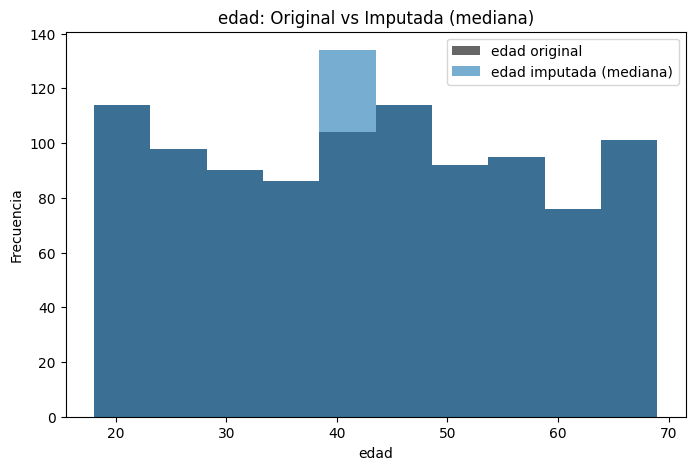

In [35]:
comparar_histogramas(df, df_mediana, "edad", "mediana")

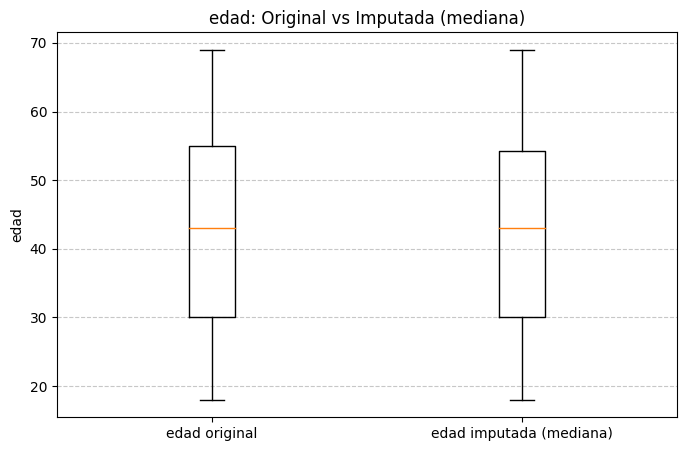

In [36]:
comparar_boxplots(df,df_mediana,'edad','mediana')

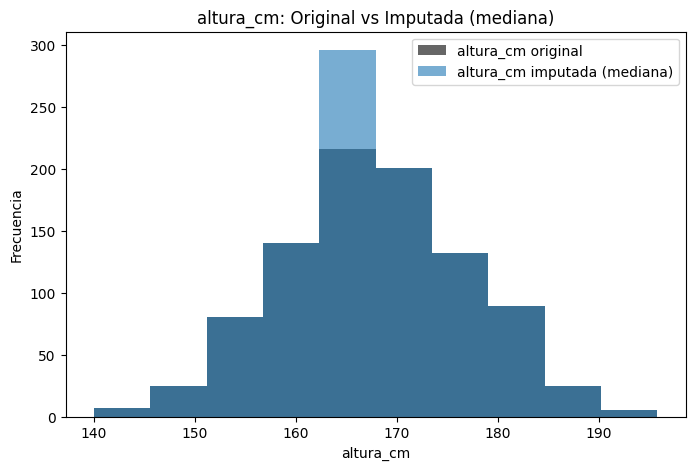

In [37]:
comparar_histogramas(df, df_mediana, "altura_cm", "mediana")

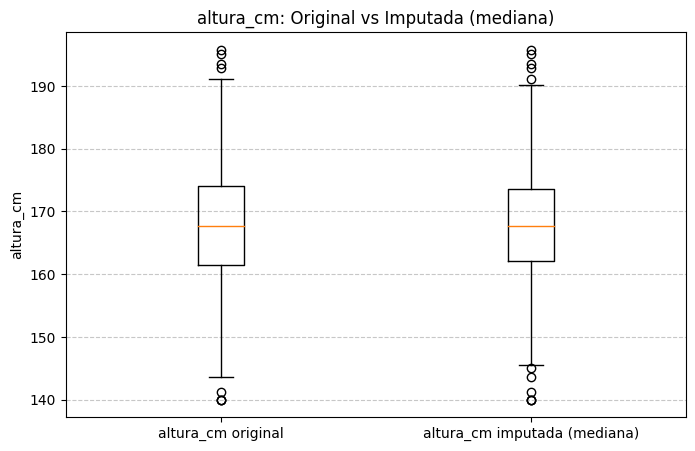

In [38]:
comparar_boxplots(df,df_mediana,'altura_cm','mediana')

Podemos observar que las distribuciones no cambiarion luego de realizar la imputacion

## Revision de normalidad imputacion Media/Mediana

In [39]:
var_med=['edad','altura_cm']
print(" Prueba de normalidad (Shapiro-Wilk) ")
for var in var_med:
    for version, data in zip(["original","mediana"],
        [df[var].dropna(), df_mediana[var]]):
        stat, p = shapiro(data)
        conclusion = "Normal" if p > 0.05 else "No normal"
        print(f"{var} ({version}): W={stat:.3f}, p={p:.4f} → {conclusion}")

 Prueba de normalidad (Shapiro-Wilk) 
edad (original): W=0.960, p=0.0000 → No normal
edad (mediana): W=0.963, p=0.0000 → No normal
altura_cm (original): W=0.998, p=0.5915 → Normal
altura_cm (mediana): W=0.995, p=0.0044 → No normal


La distribucion no cambio al hacer la imputacion 

como edad es de tipo no normal se evalua con KS y Mann-whitneyU

In [40]:
alpha = 0.05
print(" Prueba de igualdad de distribuciones \n")
for var in var_med:
    orig = df[var].dropna()
    mediana = df_mediana[var]
    ks_mediana = ks_2samp(orig, mediana)
    
    print(f"{var} (KS):")
    print(f"  Original vs Mediana → D={ks_mediana.statistic:.3f}, p={ks_mediana.pvalue:.4f} → "
          f"{'Distribuciones iguales' if ks_mediana.pvalue>alpha else 'Distribuciones diferentes'}")
    
    
    if var == "edad":
        mu_mediana = mannwhitneyu(orig, mediana, alternative="two-sided")
        print(f"{var} (Mann–Whitney U):")
        print(f"  Original vs Mediana → U={mu_mediana.statistic:.1f}, p={mu_mediana.pvalue:.4f}")
    else:
        t_mediana = ttest_ind(orig, mediana, equal_var=False)
        print(f"{var} (t de Student - Welch):")
        print(f"  Original vs Mediana → t={t_mediana.statistic:.3f}, p={t_mediana.pvalue:.4f}")
    
    print("-"*60)

 Prueba de igualdad de distribuciones 

edad (KS):
  Original vs Mediana → D=0.015, p=0.9998 → Distribuciones iguales
edad (Mann–Whitney U):
  Original vs Mediana → U=485075.0, p=0.9953
------------------------------------------------------------
altura_cm (KS):
  Original vs Mediana → D=0.040, p=0.4133 → Distribuciones iguales
altura_cm (t de Student - Welch):
  Original vs Mediana → t=0.009, p=0.9930
------------------------------------------------------------


Podemos observar que las distribuciones no cambiaron al realizar la imputacion con los resultados.Tambien se observa que los valores p en el KStest y Mann-withey-U y t-test welch son increiblemente grandes por lo que nunca rechazaran la HO.   Por lo tanto podemos concluir que la imputacion mantiene la distribucion y la media practicamente igual a los datos originales 

## Imputacion por moda

In [41]:
imp_moda = SimpleImputer(strategy="most_frequent")
df_moda = df_mediana.copy()
df_moda[["sexo"]] = imp_moda.fit_transform(df_mediana[["sexo"]])

print("\n Datos imputados con la Moda")
print(df_moda.head(10))


 Datos imputados con la Moda
  sexo        ciudad nivel_educativo segmento estado_civil  edad   altura_cm  \
0    F      Medellín             NaN        B  Unión libre  19.0  161.821754   
1    F  Barranquilla             NaN        B          NaN  52.0  167.819566   
2    M        Bogotá      Secundaria        B    Soltero/a  38.0  165.756219   
3    F        Bogotá             NaN        B     Casado/a  57.0  160.642670   
4    M          Cali         Técnico        B    Soltero/a  67.0  151.402909   
5    M  Barranquilla   Universitario      NaN          NaN  46.0  167.714614   
6    F          Cali             NaN        C          NaN  60.0  175.137932   
7    M        Bogotá   Universitario        A  Unión libre  59.0  164.865325   
8    F        Bogotá      Secundaria        C          NaN  55.0  180.519374   
9    F  Barranquilla         Técnico        B    Soltero/a  53.0  165.684648   

      ingresos  gasto_mensual  puntuacion_credito     demanda  
0  3574.753806    1832.73

In [42]:
print("\nNulos originales:\n", df.isna().sum().to_string())
print("\nNulos después de imputar con MODA:\n", df_moda.isna().sum().to_string())


Nulos originales:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150

Nulos después de imputar con MODA:
 sexo                    0
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                    0
altura_cm               0
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150


## Revision de Imputacion MODA

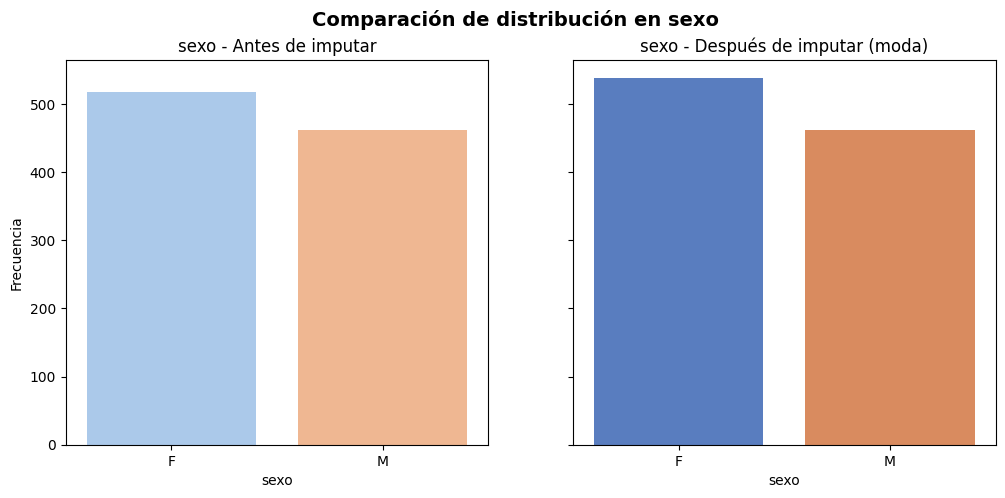

=== sexo ===
Proporciones antes:
 sexo
F    0.529
M    0.471
Name: count, dtype: float64
Proporciones después:
 sexo
F    0.538
M    0.462
Name: count, dtype: float64
Chi2 = 0.141, gl = 1, p = 0.7074 →  No se rechaza H0 (distribuciones iguales)
------------------------------------------------------------


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.countplot(x=df['sexo'], ax=axes[0], palette="pastel")
axes[0].set_title(f"{'sexo'} - Antes de imputar")
axes[0].set_ylabel("Frecuencia")

sns.countplot(x=df_moda['sexo'], ax=axes[1], palette="muted")
axes[1].set_title(f"{'sexo'} - Después de imputar (moda)")
axes[1].set_ylabel("Frecuencia")

plt.suptitle(f"Comparación de distribución en {'sexo'}", fontsize=14, weight="bold")
plt.show()

    
orig_counts = df['sexo'].value_counts().sort_index()
imp_counts = df_moda['sexo'].value_counts().sort_index()
orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)
tabla = pd.DataFrame({"original": orig_counts, "imputada": imp_counts}).T
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"=== {'sexo'} ===")
print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
print(f"Chi2 = {chi2:.3f}, gl = {dof}, p = {p:.4f} → ",
          "No se rechaza H0 (distribuciones iguales)" if p > 0.05 else "Se rechaza H0 (distribuciones diferentes)")
print("-"*60)

Podemos observar que las distribucion entre la variables categoricas se mantienen incluso despues de la imputacion, y el metodo de chi2  dio mayor que 0.05. por lo que podemos afirmar que no cambia la distribucion de las variable sexo cuando se aplica la imputacion por MODA

## Imputacion por KNN numericas

In [44]:
num_knn=['gasto_mensual','demanda']

In [45]:
knn = KNNImputer(n_neighbors=5, weights="distance")
df_knn = df_moda.copy()
df_knn[num_knn] = knn.fit_transform(df_knn[num_knn])

In [46]:
print("Nulos antes:\n", df[num_knn].isna().sum())
print("\nNulos después (KNN):\n", df_knn[num_knn].isna().sum())

Nulos antes:
 gasto_mensual    250
demanda          150
dtype: int64

Nulos después (KNN):
 gasto_mensual    0
demanda          0
dtype: int64


## Revision de Imputacion por KNN(numericas)

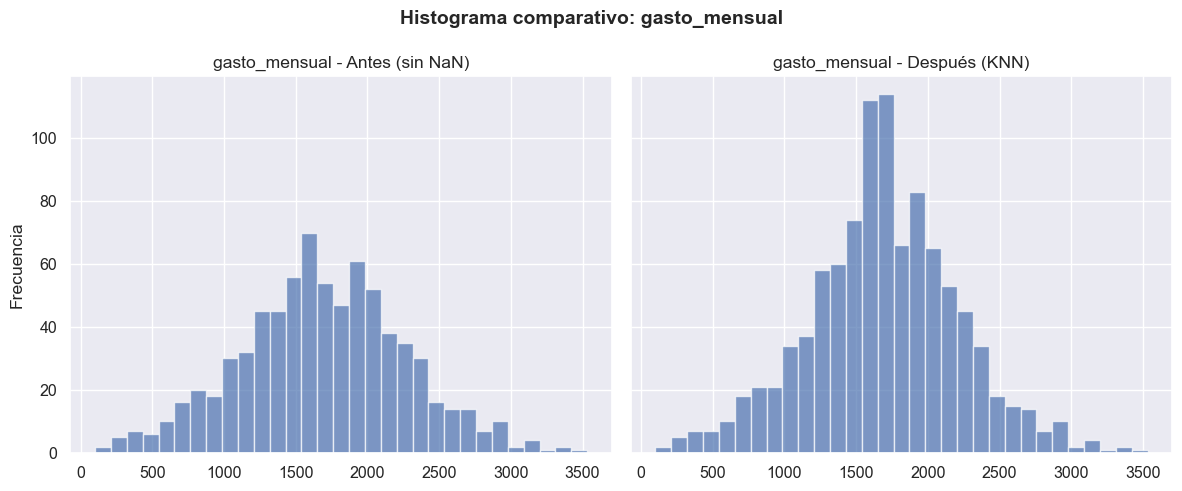

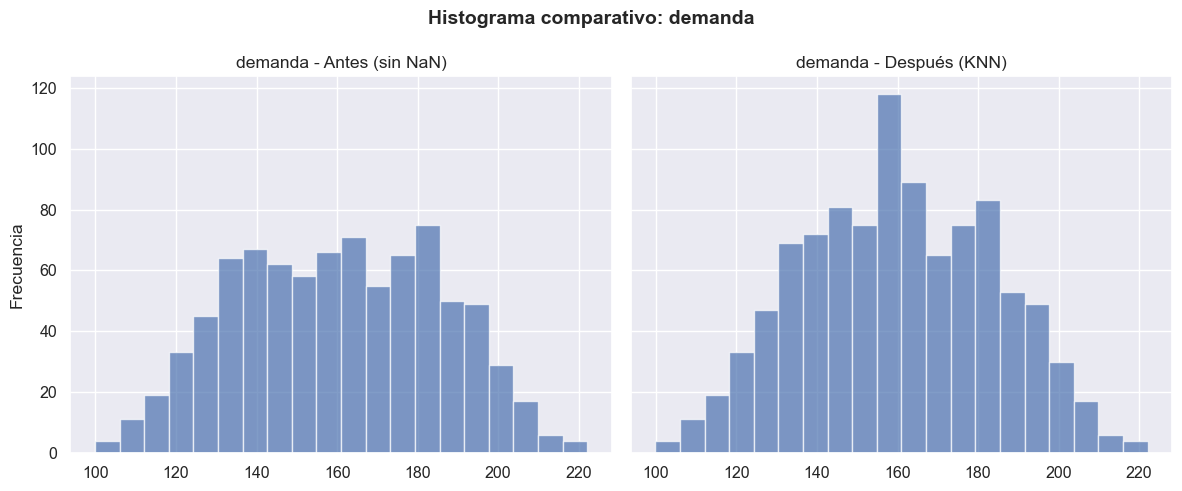

In [47]:
sns.set(style="darkgrid", font_scale=1.05)
for col in num_knn:
   
    base = df[col].dropna()
    after = df_knn[col]
    bins = np.histogram_bin_edges(np.concatenate([base.values, after.values]), bins="auto")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    axes[0].hist(base, bins=bins, alpha=0.7)
    axes[0].set_title(f"{col} - Antes (sin NaN)")
    axes[0].set_ylabel("Frecuencia")

    axes[1].hist(after, bins=bins, alpha=0.7)
    axes[1].set_title(f"{col} - Después (KNN)")

    plt.suptitle(f"Histograma comparativo: {col}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

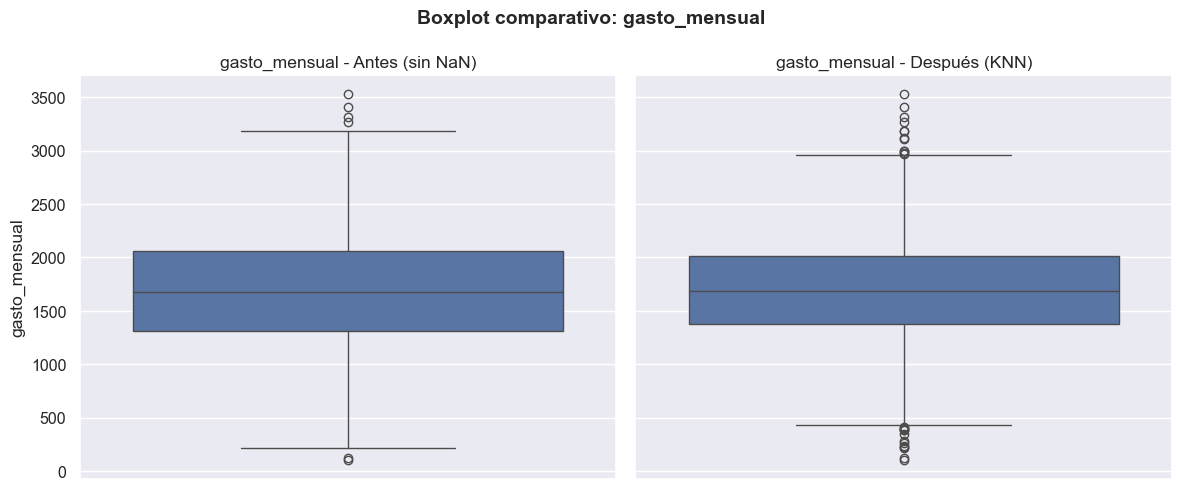

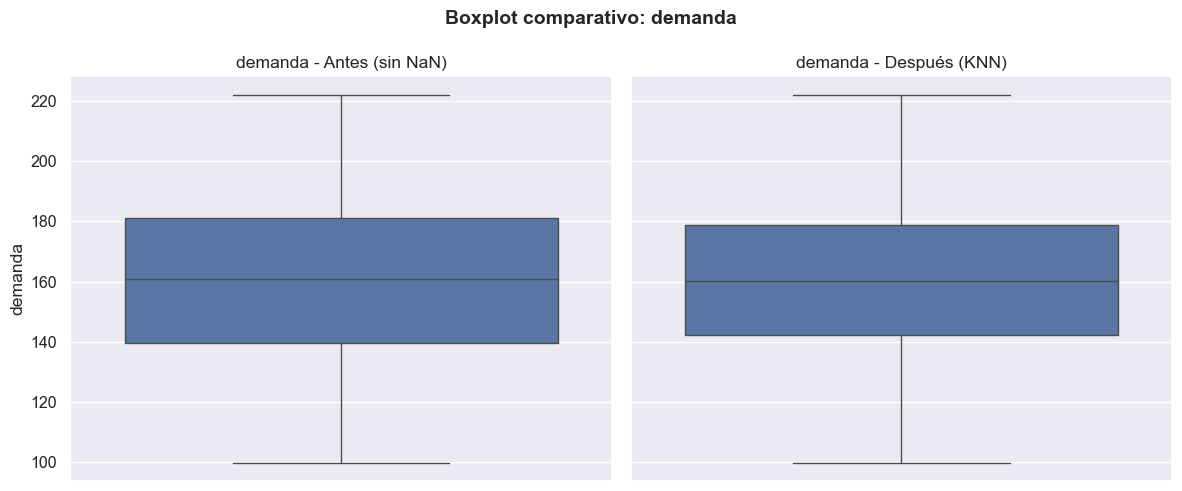

In [48]:
sns.set(style="darkgrid", font_scale=1.05)

for col in num_knn:
    base = df[col].dropna()
    after = df_knn[col]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Boxplot antes
    sns.boxplot(y=base, ax=axes[0])
    axes[0].set_title(f"{col} - Antes (sin NaN)")
    axes[0].set_ylabel(col)

    # Boxplot después
    sns.boxplot(y=after, ax=axes[1])
    axes[1].set_title(f"{col} - Después (KNN)")

    plt.suptitle(f"Boxplot comparativo: {col}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

Podemos observar que la distribucion en ambos casos se volvio un poco mas centrada que antes en comparacion a como estaban antes las 2 variables pero su forma general se mantiene. Esto es esperado de KNN

In [49]:
alpha = 0.05
res = []

def cohens_d(x, y):
    
    x, y = np.asarray(x), np.asarray(y)
    sx2, sy2 = x.var(ddof=1), y.var(ddof=1)
    n1, n2 = len(x), len(y)
    sp = np.sqrt(((n1-1)*sx2 + (n2-1)*sy2)/(n1+n2-2)) if (n1+n2-2)>0 else np.nan
    return (x.mean()-y.mean())/sp if sp>0 else np.nan

def rank_biserial_from_u(u, n1, n2):
    return 1 - (2*u)/(n1*n2)

print("\n Evaluación analítica ")
for col in num_knn:
    x = df[col].dropna().values      
    y = df_knn[col].values               

    sh_x = shapiro(x) if len(x) >= 3 else None
    sh_y = shapiro(y) if len(y) >= 3 else None
    normal_x = (sh_x is not None) and (sh_x.pvalue > alpha)
    normal_y = (sh_y is not None) and (sh_y.pvalue > alpha)

    ks = ks_2samp(x, y)

   
    if normal_x and normal_y:
        
        tt = ttest_ind(x, y, equal_var=False)
        eff = cohens_d(x, y)
        test_name = "t de Student (Welch)"
        stat = tt.statistic; p = tt.pvalue; eff_name = "Cohen d"
    else:
        mu = mannwhitneyu(x, y, alternative="two-sided")
        eff = rank_biserial_from_u(mu.statistic, len(x), len(y))
        test_name = "Mann–Whitney U"
        stat = mu.statistic; p = mu.pvalue; eff_name = "r biserial"

    print(f"\n--- {col} ---")
    if sh_x is not None and sh_y is not None:
        print(f"Shapiro original: W={sh_x.statistic:.3f}, p={sh_x.pvalue:.4f} -> {'Normal' if normal_x else 'No normal'}")
        print(f"Shapiro KNN     : W={sh_y.statistic:.3f}, p={sh_y.pvalue:.4f} -> {'Normal' if normal_y else 'No normal'}")

    print(f"KS (orig vs KNN): D={ks.statistic:.3f}, p={ks.pvalue:.4f} -> "
          f"{'Distribuciones iguales' if ks.pvalue>alpha else 'Distribuciones diferentes'}")

    print(f"{test_name}: stat={stat:.3f}, p={p:.4f} -> "
          f"{'Sin diferencia' if p>alpha else 'Diferencia significativa'}")
    print(f"Tamaño de efecto ({eff_name}) = {eff:.3f}")

    res.append({
        "variable": col,
        "KS_p": ks.pvalue,
        "test": test_name,
        "p_media_rangos": p,
        "effect_metric": eff_name,
        "effect_size": eff
    })

pd.DataFrame(res)


 Evaluación analítica 

--- gasto_mensual ---
Shapiro original: W=0.998, p=0.6746 -> Normal
Shapiro KNN     : W=0.995, p=0.0015 -> No normal
KS (orig vs KNN): D=0.038, p=0.5434 -> Distribuciones iguales
Mann–Whitney U: stat=374228.000, p=0.9412 -> Sin diferencia
Tamaño de efecto (r biserial) = 0.002

--- demanda ---
Shapiro original: W=0.985, p=0.0000 -> No normal
Shapiro KNN     : W=0.992, p=0.0000 -> No normal
KS (orig vs KNN): D=0.034, p=0.6406 -> Distribuciones iguales
Mann–Whitney U: stat=426338.000, p=0.9070 -> Sin diferencia
Tamaño de efecto (r biserial) = -0.003


,variable,KS_p,test,p_media_rangos,effect_metric,effect_size
0,gasto_mensual,0.543384,Mann–Whitney U,0.941210,r biserial,0.002059
1,demanda,0.640569,Mann–Whitney U,0.907012,r biserial,-0.003148


Si bien la normalidad de la variable gasto_mensual cambio analizando las otras metricas, podemos observar que la distribucion se mantiene debido a los resultados del KStest Mann-withney y r-biseral por lo que KNN no cambia la distribucion de la variable gasto mensual.

En contraste la variable demanda si mantiene su distribucion y su no normalidad con resultados similares en los test realizados. 

## Imputacion por HotDeck

In [ ]:
df_hot=df_knn.copy()
df_hot['ciudad_imp'] = hot_deck_group(df_hot, col='ciudad', group='sexo')
df_hot["ciudad_imp"] = df_hot["ciudad_imp"].astype("category")
df_hot["ciudad_imp"] = df_hot["ciudad_imp"].cat.set_categories(df_hot["ciudad_imp"].dropna().unique())
df_hot['nivel_educativo_imp'] = hot_deck_group(df_hot, col='nivel_educativo', group='sexo')
df_hot["nivel_educativo_imp"] = df_hot["nivel_educativo_imp"].astype("category")
df_hot["nivel_educativo_imp"] = df_hot["nivel_educativo_imp"].cat.set_categories(df_hot["nivel_educativo_imp"].dropna().unique())

In [51]:
print("\nNulos originales:\n", df.isna().sum().to_string())
print("\nNulos después de imputar con hotdeck:\n", df_hot.isna().sum().to_string())


Nulos originales:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150

Nulos después de imputar con hotdeck:
 sexo                     0
ciudad                  50
nivel_educativo        100
segmento               200
estado_civil           350
edad                     0
altura_cm                0
ingresos               120
gasto_mensual            0
puntuacion_credito     500
demanda                  0
ciudad_imp               0
nivel_educativo_imp      0


## Revision de imputacion por HotDeck

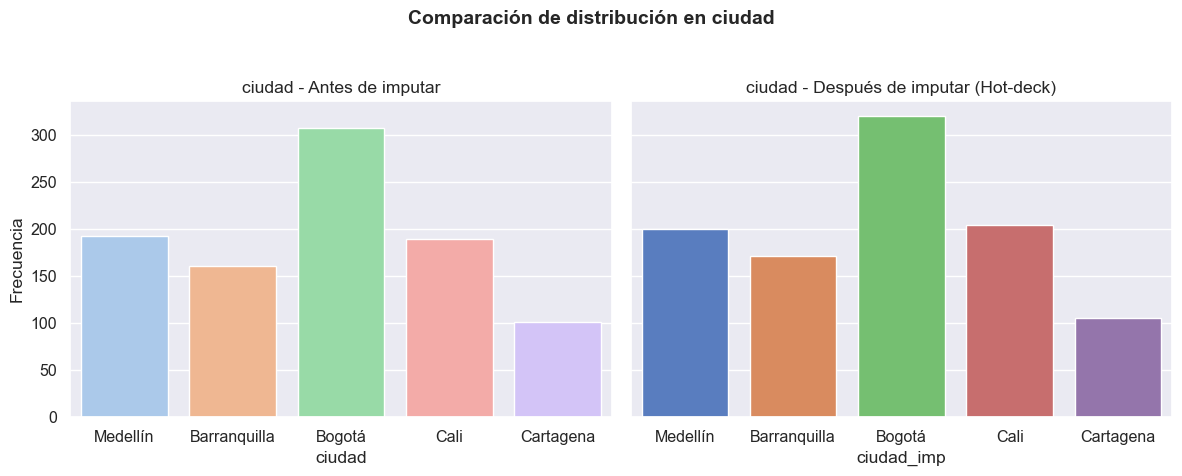

=== ciudad ===
Proporciones antes:
 ciudad
Barranquilla    0.169
Bogotá          0.323
Cali            0.199
Cartagena       0.106
Medellín        0.202
Name: count, dtype: float64
Proporciones después:
 ciudad_imp
Barranquilla    0.171
Bogotá          0.320
Cali            0.204
Cartagena       0.105
Medellín        0.200
Name: count, dtype: float64
Chi² = 0.102, gl = 4, p = 0.9987 →  No se rechaza H₀ (distribuciones iguales)
Cramér's V = 0.007 (≈0: muy similar; 0.1: pequeño; 0.3: mediano; 0.5: grande)
------------------------------------------------------------


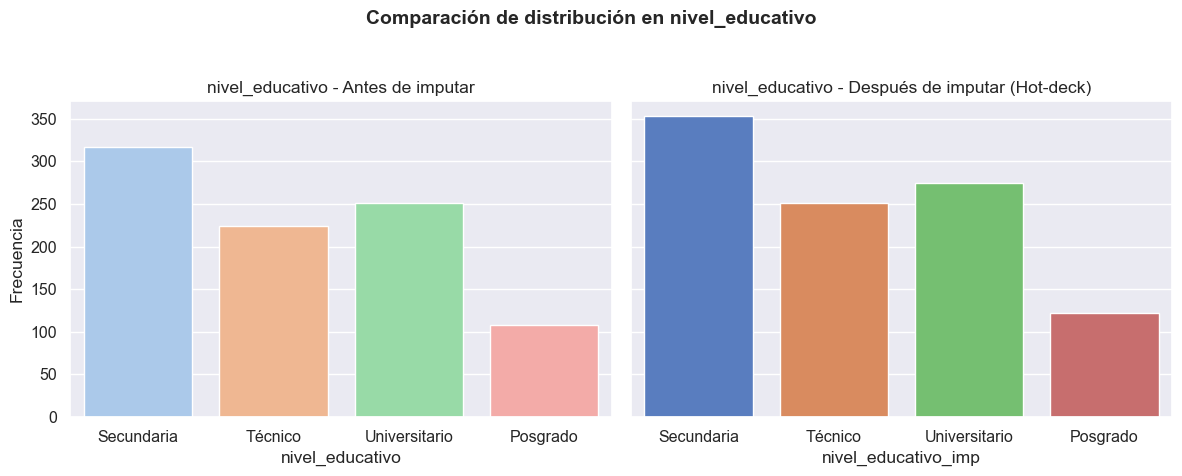

=== nivel_educativo ===
Proporciones antes:
 nivel_educativo
Posgrado         0.120
Secundaria       0.352
Técnico          0.249
Universitario    0.279
Name: count, dtype: float64
Proporciones después:
 nivel_educativo_imp
Posgrado         0.122
Secundaria       0.353
Técnico          0.251
Universitario    0.274
Name: count, dtype: float64
Chi² = 0.066, gl = 3, p = 0.9956 →  No se rechaza H₀ (distribuciones iguales)
Cramér's V = 0.006 (≈0: muy similar; 0.1: pequeño; 0.3: mediano; 0.5: grande)
------------------------------------------------------------


In [52]:
var = ['ciudad','nivel_educativo']
for var in var:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.countplot(
    x=df_hot[var],
    ax=axes[0],
    palette="pastel",
    order=df_hot[var].dropna().unique()
)
    axes[0].set_title(f"{var} - Antes de imputar")
    axes[0].set_ylabel("Frecuencia")

    sns.countplot(
    x=df_hot[f"{var}_imp"],
    ax=axes[1],
    palette="muted",
    order=df_hot[var].dropna().unique()  # se ordena con base en el original
)
    axes[1].set_title(f"{var} - Después de imputar (Hot-deck)")
    axes[1].set_ylabel("Frecuencia")

    plt.suptitle(f"Comparación de distribución en {var}", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta el espacio para el título
    plt.show()

    # === Comparación numérica (Chi² + Cramér’s V) ===
    orig_counts = df_hot[var].value_counts().sort_index()
    imp_counts = df_hot[f"{var}_imp"].value_counts().sort_index()
    orig_counts, imp_counts = orig_counts.align(imp_counts, fill_value=0)

    # Tabla cruzada
    ct = pd.DataFrame({"original": orig_counts, "imputada": imp_counts})

    # Aplicar chi²
    chi2, p, dof, exp = chi2_contingency(ct.T)
    v = cramers_v_imp(ct.T)  # Asegúrate de tener definida cramers_v_imp

    # Resultados
    print(f"=== {var} ===")
    print("Proporciones antes:\n", (orig_counts / orig_counts.sum()).round(3))
    print("Proporciones después:\n", (imp_counts / imp_counts.sum()).round(3))
    print(f"Chi² = {chi2:.3f}, gl = {dof}, p = {p:.4f} → ",
      "No se rechaza H₀ (distribuciones iguales)" if p > 0.05 else "Se rechaza H₀ (distribuciones diferentes)")
    print(f"Cramér's V = {v:.3f} (≈0: muy similar; 0.1: pequeño; 0.3: mediano; 0.5: grande)")
    print("-" * 60)

Podemos observar que la imputacion por Hotdeck no altero significativamente la distribucion de la variable ciudad, Tanto el p-valor (0.9996) como Cramér’s V (0.005) indican que las distribuciones son prácticamente idénticas. Lo mismo ocurre con la variable de nivel educativo que con un pvalor de 0.9956 y cramer de 0.006 nos dice lo mismo. Por lo que el metodo de imputacion fue adecuado para este caso.

In [53]:
df_hot=df_hot.drop(columns=['ciudad','nivel_educativo'])

## Imputacion por regresion

In [54]:
df_reg = df_hot.copy()

In [55]:
X = pd.get_dummies(df_reg[["edad", "nivel_educativo_imp", "ciudad_imp","gasto_mensual"]],
                   drop_first=True)
y = df_reg["ingresos"]

In [56]:
mask_train = y.notna()

In [57]:
model = LinearRegression()
model.fit(X[mask_train], y[mask_train])

LinearRegression()

In [58]:
mask_pred = y.isna()
y_pred = model.predict(X[mask_pred])

In [59]:
df_reg.loc[mask_pred, "ingresos"] = y_pred

In [60]:
nulos_antes = df["ingresos"].isna().sum()
pct_antes = (nulos_antes / len(df)) * 100

print(f"Nulos en 'ingresos' ANTES de imputar: {nulos_antes} ({pct_antes:.2f}%)")


nulos_despues = df_reg["ingresos"].isna().sum()
pct_despues = (nulos_despues / len(df_reg)) * 100

print(f"Nulos en 'ingresos' DESPUÉS de imputar: {nulos_despues} ({pct_despues:.2f}%)")

Nulos en 'ingresos' ANTES de imputar: 120 (12.00%)
Nulos en 'ingresos' DESPUÉS de imputar: 0 (0.00%)


## Revision de Imputacion de Regresion

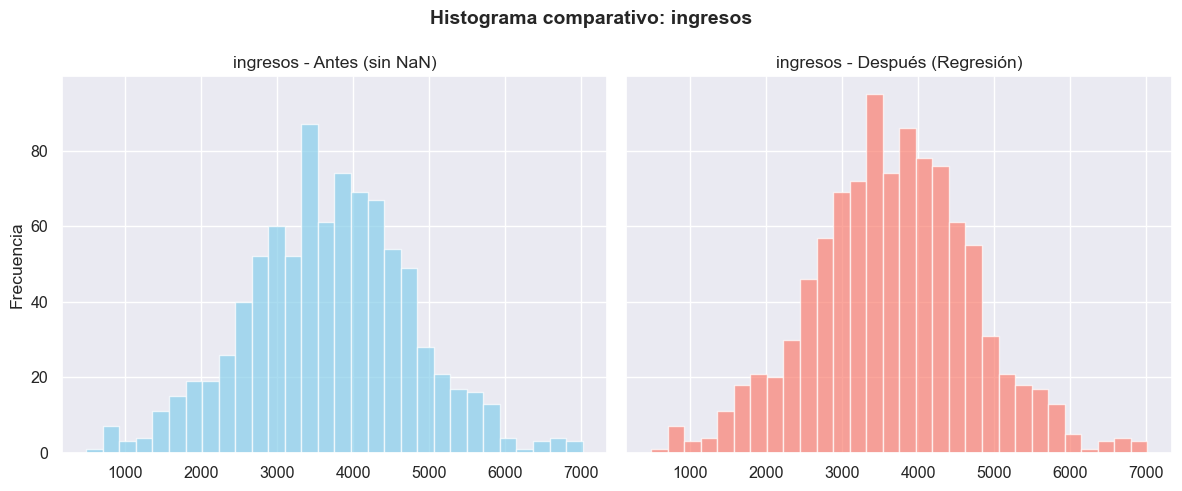

In [61]:
col = "ingresos"
base = df[col].dropna()
after = df_reg[col]

bins = np.histogram_bin_edges(np.concatenate([base.values, after.values]), bins="auto")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].hist(base, bins=bins, alpha=0.7, color="skyblue")
axes[0].set_title(f"{col} - Antes (sin NaN)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(after, bins=bins, alpha=0.7, color="salmon")
axes[1].set_title(f"{col} - Después (Regresión)")

plt.suptitle(f"Histograma comparativo: {col}", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

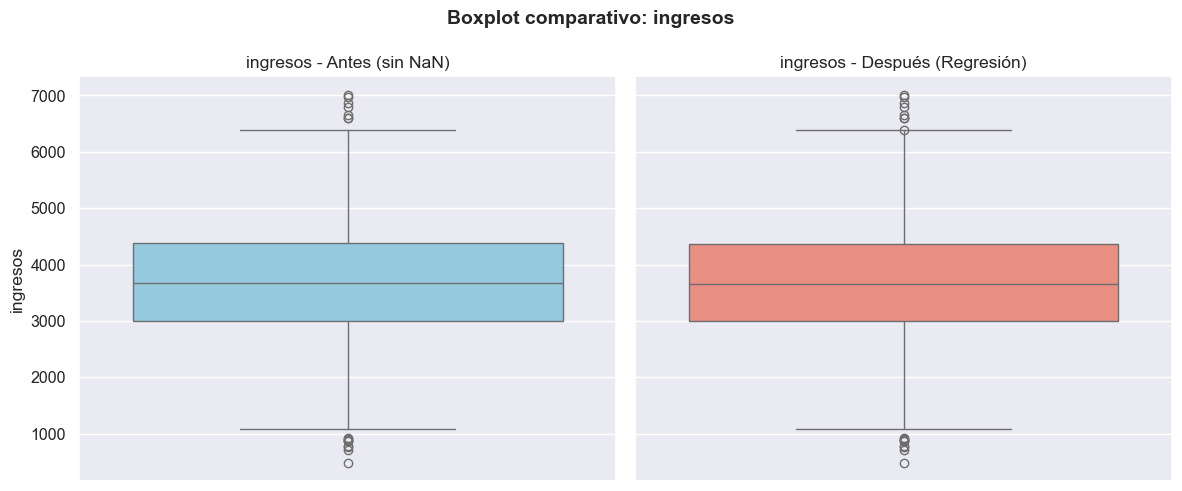

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.boxplot(y=base, ax=axes[0], color="skyblue")
axes[0].set_title(f"{col} - Antes (sin NaN)")
axes[0].set_ylabel(col)
sns.boxplot(y=after, ax=axes[1], color="salmon")
axes[1].set_title(f"{col} - Después (Regresión)")

plt.suptitle(f"Boxplot comparativo: {col}", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

Podemos observar que la distribucion se mantiene en ingresos despues de imputar, algunos valores mas altos que otros debido a que la imputacion hizo a la distribucion mas uniforme  

In [63]:
alpha = 0.05
x = base.values
y_new = after.values


sh_x = shapiro(x)
sh_y = shapiro(y_new)
normal_x = sh_x.pvalue > alpha
normal_y = sh_y.pvalue > alpha

print(f"Shapiro original: W={sh_x.statistic:.3f}, p={sh_x.pvalue:.4f} -> {'Normal' if normal_x else 'No normal'}")
print(f"Shapiro imputado: W={sh_y.statistic:.3f}, p={sh_y.pvalue:.4f} -> {'Normal' if normal_y else 'No normal'}")

ks = ks_2samp(x, y_new)
print(f"KS: D={ks.statistic:.3f}, p={ks.pvalue:.4f} -> {'Distribuciones iguales' if ks.pvalue>alpha else 'Distribuciones diferentes'}")

if normal_x and normal_y:
    tt = ttest_ind(x, y_new, equal_var=False)
    print(f"T de Student (Welch): t={tt.statistic:.3f}, p={tt.pvalue:.4f} -> "
          f"{'Sin diferencia' if tt.pvalue>alpha else 'Diferencia significativa'}")
else:
    mu = mannwhitneyu(x, y_new, alternative="two-sided")
    print(f"Mann–Whitney U: U={mu.statistic:.3f}, p={mu.pvalue:.4f} -> "
          f"{'Sin diferencia' if mu.pvalue>alpha else 'Diferencia significativa'}")

Shapiro original: W=0.998, p=0.3244 -> Normal
Shapiro imputado: W=0.998, p=0.2108 -> Normal
KS: D=0.013, p=1.0000 -> Distribuciones iguales
T de Student (Welch): t=0.283, p=0.7771 -> Sin diferencia


Podemos observar que el p-valor de shapiro wilk sigue siendo mayor que 0.05 por lo que la variable sigue siendo normal, y el pvalor de Ks test dio un valor bastante alto por lo que las distribuciones son iguales en ambos casos y con un p-valor de 0.81 en el t-student de welch no hubo un cambio significativo en las medias. Por lo tanto la distribucion se mantuvo luego de la imputacion

In [80]:
print("\nNulos originales:\n", df.isna().sum().to_string())
print("\nNulos después de imputar con regresion:\n", df_reg.isna().sum().to_string())


Nulos originales:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150

Nulos después de imputar con regresion:
 sexo                     0
segmento               200
estado_civil             0
edad                     0
altura_cm                0
ingresos                 0
gasto_mensual            0
puntuacion_credito       0
demanda                  0
ciudad_imp               0
nivel_educativo_imp      0


## Variables sin imputar 

debido a que estas variables son de tipo MNAR y tienen un porcentaje muy alto de NA, se decidio que no se debian imputar, en su lugar se les asigna una categoria missing a esas 2 variables 

In [77]:
df_reg['estado_civil']=df_reg['estado_civil'].fillna('missing')
df_reg['puntuacion_credito']=df_reg['puntuacion_credito'].fillna('missing')

In [79]:
print("\nNulos originales:\n", df.isna().sum().to_string())
print("\nNulos después de agregar categoria:\n", df_reg.isna().sum().to_string())


Nulos originales:
 sexo                   20
ciudad                 50
nivel_educativo       100
segmento              200
estado_civil          350
edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150

Nulos después de agregar categoria:
 sexo                     0
segmento               200
estado_civil             0
edad                     0
altura_cm                0
ingresos                 0
gasto_mensual            0
puntuacion_credito       0
demanda                  0
ciudad_imp               0
nivel_educativo_imp      0
